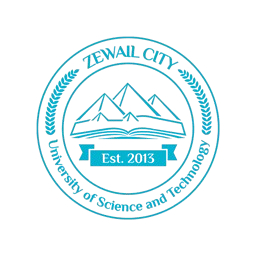

---
# Haldane Model II

## 2D Chern Insulator on Honeycomb Lattice
### *Driven by Circular Laser Field*

The **Haldane model** realizes the quantum anomalous Hall effect on a
honeycomb lattice without a net magnetic flux. Its three ingredients —
nearest-neighbor hopping $t_1$, complex next-nearest-neighbor hopping
$t_2 e^{i\phi}$, and staggered sublattice potential $M$ — combine to
produce a bulk Chern number $C \in \{-1, 0, +1\}$.

Under a **circularly polarized** laser field the Peierls substitution
$\mathbf{k} \to \mathbf{k} + \mathbf{A}(t)$ modifies all hopping phases
simultaneously. Because the honeycomb has **two inequivalent valleys**
$K$ and $K'$, the circular drive can selectively close the gap at one
valley while leaving the other open — enabling valley-selective
topological transitions inaccessible with linear polarization.

$$
A_x(t) = \frac{F_0}{\omega}\cos\omega t, \qquad
A_y(t) = \frac{F_0}{\omega}\sin\omega t
$$

**Key additions over QWZ**

| Feature | QWZ | Haldane |
|---|---|---|
| Lattice | Square | **Honeycomb** (two sublattices, C₃ symmetry) |
| Valleys | None | **K and K'** (Dirac points) |
| NNN hopping | None | $t_2 e^{i\phi}$ — breaks TR without net flux |
| Symmetry | C₄ | **C₃** — different HHG selection rules |
| Drive effect | Uniform BZ shift | **Valley-selective** gap control |
| Phase diagram | $(t_0, F_0)$ | $(M/t_2, \phi)$ + drive |

In [1]:
# Main Libraries
import sympy as sp
from IPython.display import display, Math, Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.gridspec import GridSpec
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, BoundaryNorm
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams.update({
    'figure.dpi'    : 120,
    'axes.grid'     : True,
    'grid.linestyle': ':',
    'grid.linewidth': 0.4,
    'font.size'     : 11,
})

## Symbolic Analysis

### 1. Lattice Geometry & Peierls Substitution

In [2]:
# Symbolic: Lattice & Peierls 

kx_s, ky_s, Ax_s, Ay_s = sp.symbols('k_x k_y A_x A_y', real=True)
t1_s, t2_s, M_s, phi_s, a_s = sp.symbols('t_1 t_2 M phi a',
                                           real=True, positive=True)

# Nearest-neighbor (NN) vectors  a_j  (A→B)
a1_s = sp.Matrix([0,                   -a_s          ])
a2_s = sp.Matrix([ sp.sqrt(3)/2 * a_s,  sp.Rational(1,2)*a_s])
a3_s = sp.Matrix([-sp.sqrt(3)/2 * a_s,  sp.Rational(1,2)*a_s])
nn_vecs = [a1_s, a2_s, a3_s]

# Next-nearest-neighbor (NNN) vectors  b_j  (A→A, with sign)
b1_s = sp.Matrix([sp.sqrt(3)*a_s,          0                 ])
b2_s = sp.Matrix([-sp.sqrt(3)/2*a_s,      -sp.Rational(3,2)*a_s])
b3_s = sp.Matrix([-sp.sqrt(3)/2*a_s,       sp.Rational(3,2)*a_s])
nnn_vecs = [b1_s, b2_s, b3_s]

display(Math(r"\text{NN vectors } \mathbf{a}_j \text{ (A→B):}"))
for j, v in enumerate(nn_vecs, 1):
    display(Math(fr"\mathbf{{a}}_{j} = {sp.latex(v.T)}"))

display(Math(r"\text{NNN vectors } \mathbf{b}_j \text{ (A→A):}"))
for j, v in enumerate(nnn_vecs, 1):
    display(Math(fr"\mathbf{{b}}_{j} = {sp.latex(v.T)}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [3]:
display(Math(
    r"\text{Peierls substitution: } "
    r"\mathbf{k}\cdot\mathbf{a}_j \;\to\; "
    r"(\mathbf{k}+\mathbf{A})\cdot\mathbf{a}_j "
    r"= k_x a_j^x + k_y a_j^y + A_x a_j^x + A_y a_j^y"))
display(Math(
    r"\text{Complex NNN phase: }"
    r"\phi \;\to\; \phi + \mathbf{A}\cdot\mathbf{b}_j "
    r"\text{ (not applicable here — phase enters via } k\cdot b_j\text{)}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### 2. Bloch Hamiltonian after Peierls Substitution

In [4]:
# Bloch Hamiltonian 

k_vec = sp.Matrix([kx_s + Ax_s, ky_s + Ay_s])

# NN hopping: f(k,A) = -t1 Σ exp(i(k+A)·a_j)
f_kA = -t1_s * sum(
    sp.exp(sp.I * k_vec.dot(v)) for v in nn_vecs)

# d-vector components
dx_s_expr = sp.re(sp.expand(f_kA))
dy_s_expr = sp.im(sp.expand(f_kA))

# NNN hopping: dz = M - 2t2 sin(phi) Σ sin((k+A)·b_j)
dz_s_expr = M_s - 2*t2_s*sp.sin(phi_s) * sum(
    sp.sin(k_vec.dot(v)) for v in nnn_vecs)

sx_s = sp.Matrix([[0,1],[1,0]])
sy_s = sp.Matrix([[0,-sp.I],[sp.I,0]])
sz_s = sp.Matrix([[1,0],[0,-1]])

H_H_sym = dz_s_expr*sz_s + sp.Matrix([
    [0,              f_kA          ],
    [sp.conjugate(f_kA), 0        ]
])

display(Math(r"H(\mathbf{k},\mathbf{A}) = \begin{pmatrix} d_z & f \\ f^* & -d_z \end{pmatrix}"))
display(Math(fr"f(\mathbf{{k}},\mathbf{{A}}) = -t_1\sum_j e^{{i(\mathbf{{k}}+\mathbf{{A}})\cdot\mathbf{{a}}_j}}"))
display(Math(fr"d_z = M - 2t_2\sin\phi\sum_j\sin((\mathbf{{k}}+\mathbf{{A}})\cdot\mathbf{{b}}_j)"))
display(Math(r"\text{Explicit } d_x:"))
display(Math(sp.latex(sp.simplify(
    -t1_s*sum(sp.cos(k_vec.dot(v)) for v in nn_vecs)))))
display(Math(r"\text{Explicit } d_y:"))
display(Math(sp.latex(sp.simplify(
    -t1_s*sum(sp.sin(k_vec.dot(v)) for v in nn_vecs)))))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### 3. Eigenvalues & Gap Closing

In [5]:
# Eigenvalues 

E_H = sp.sqrt(
    t1_s**2 * sum(1 + 2*sp.cos(k_vec.dot(nn_vecs[i]-nn_vecs[j]))
                  for i in range(3) for j in range(i+1,3))
    + t1_s**2 * 3 + dz_s_expr**2)

display(Math(r"E_\pm(\mathbf{k},\mathbf{A}) = \pm|\mathbf{d}(\mathbf{k},\mathbf{A})|"
             r"= \pm\sqrt{d_x^2+d_y^2+d_z^2}"))

# Gap closing at K and K' (symbolic)
# At A=0: K = (4π/(3√3 a), 0)
K_s  = sp.Matrix([4*sp.pi/(3*sp.sqrt(3)*a_s), 0])
Kp_s = sp.Matrix([-4*sp.pi/(3*sp.sqrt(3)*a_s), 0])

dz_K  = dz_s_expr.subs([(kx_s, K_s[0]),  (ky_s, K_s[1]),
                          (Ax_s, 0), (Ay_s, 0)])
dz_Kp = dz_s_expr.subs([(kx_s, Kp_s[0]), (ky_s, Kp_s[1]),
                          (Ax_s, 0), (Ay_s, 0)])

display(Math(r"\text{Gap closing at } K:"))
display(Math(fr"d_z(K) = {sp.latex(sp.simplify(dz_K))} = 0 "
             fr"\Rightarrow M = 3\sqrt{{3}}\,t_2\sin\phi"))
display(Math(r"\text{Gap closing at } K':"))
display(Math(fr"d_z(K') = {sp.latex(sp.simplify(dz_Kp))} = 0 "
             fr"\Rightarrow M = -3\sqrt{{3}}\,t_2\sin\phi"))
display(Math(
    r"\text{Chern number: }"
    r"C = \begin{cases} "
    r"+1 & 0<M<3\sqrt{3}t_2\sin\phi \\"
    r"-1 & -3\sqrt{3}t_2\sin\phi<M<0 \\"
    r"0  & |M|>3\sqrt{3}t_2|\sin\phi|"
    r"\end{cases}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### 4. Eigenvectors & Berry Connection

In [6]:
# Eigenvectors & Berry curvature

theta_s, varphi_s = sp.symbols('theta varphi', real=True)

# Bloch sphere: cos θ = dz/|d|, φ = arg(dx + i dy)
psi_minus_H = sp.Matrix([
     sp.cos(theta_s/2)*sp.exp(-sp.I*varphi_s/2),
     sp.sin(theta_s/2)*sp.exp( sp.I*varphi_s/2)
])
psi_plus_H = sp.Matrix([
    -sp.sin(theta_s/2)*sp.exp(-sp.I*varphi_s/2),
     sp.cos(theta_s/2)*sp.exp( sp.I*varphi_s/2)
])

display(Math(
    r"\cos\theta = \frac{d_z}{|\mathbf{d}|},\quad"
    r"\varphi = \arg(d_x + id_y)"))
display(Math(r"|\psi_-\rangle = " + sp.latex(psi_minus_H)))
display(Math(r"|\psi_+\rangle = " + sp.latex(psi_plus_H)))
display(Math(
    r"\text{Berry curvature: }"
    r"\Omega_z(\mathbf{k}) = -\frac{1}{2}\hat{\mathbf{d}}\cdot"
    r"\left(\partial_{k_x}\hat{\mathbf{d}}\times\partial_{k_y}\hat{\mathbf{d}}\right)"))
display(Math(
    r"C = \frac{1}{2\pi}\int_\mathrm{BZ}\Omega_z(\mathbf{k})\,d^2k \in \mathbb{Z}"))
display(Math(
    r"\text{Under drive: }\Omega_z(\mathbf{k},\mathbf{A}(t))"
    r"\text{ — Berry curvature flows through BZ as A(t) circles}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### 5. Current Operator

In [7]:
# Current Operator

Jx_H_offdiag = -sp.diff(f_kA, Ax_s)
Jy_H_offdiag = -sp.diff(f_kA, Ay_s)
Jz_H_dz      = -sp.diff(dz_s_expr, Ax_s)  # dz contributes via NNN

display(Math(r"\hat{\mathbf{J}} = -\nabla_\mathbf{A} H"))
display(Math(
    r"J_x = \begin{pmatrix} -\partial_{A_x}d_z & "
    r"-\partial_{A_x}f \\ -\partial_{A_x}f^* & "
    r"+\partial_{A_x}d_z\end{pmatrix}"))
display(Math(r"-\partial_{A_x}f ="))
display(Math(sp.latex(sp.simplify(Jx_H_offdiag))))
display(Math(r"-\partial_{A_y}f ="))
display(Math(sp.latex(sp.simplify(Jy_H_offdiag))))
display(Math(
    r"\text{NNN contribution to } J_x \text{ from } d_z\sigma_z:"))
display(Math(sp.latex(sp.simplify(-sp.diff(dz_s_expr, Ax_s)))))
display(Math(
    r"\text{Physical: } J_x = J_x^\mathrm{NN} + J_x^\mathrm{NNN}"
    r"\quad \text{(both NN and NNN bonds carry current)}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Numerical Analysis

### 6. Laser Parameters

In [8]:
# Numerical Parameters

# Lattice constant
a = 1.0

# Honeycomb geometry (numerical)
delta1 = np.array([0.0,              -a         ])
delta2 = np.array([ np.sqrt(3)/2*a,   0.5*a    ])
delta3 = np.array([-np.sqrt(3)/2*a,   0.5*a    ])
nn_num = [delta1, delta2, delta3]

b1_num = np.array([ np.sqrt(3)*a,     0.0       ])
b2_num = np.array([-np.sqrt(3)/2*a,  -1.5*a    ])
b3_num = np.array([-np.sqrt(3)/2*a,   1.5*a    ])
nnn_num = [b1_num, b2_num, b3_num]

# Model parameters
t1_val  = 1.0
t2_val  = 0.3
M_val   = 0.2          # staggered mass  (C=+1 for small |M|)
phi_val = np.pi/2      # Haldane phase   (maximum topological gap)
M_triv  = 4.0          # trivial (|M| > 3√3 t2 sin φ ≈ 1.56)

# High-symmetry points
K_pt  = np.array([ 4*np.pi/(3*np.sqrt(3)*a), 0.0])
Kp_pt = np.array([-4*np.pi/(3*np.sqrt(3)*a), 0.0])
G_pt  = np.array([0.0, 0.0])
M_pt  = np.array([np.pi/(np.sqrt(3)*a), np.pi/a])

# Laser — circular polarization
F0    = 2.5
omega = 1.5
T_per = 2*np.pi / omega
n_cyc = 8
t_max = n_cyc * T_per
dt    = T_per / 400
t_arr = np.arange(0, t_max, dt)
Nt    = len(t_arr)

A_x_arr = (F0/omega) * np.cos(omega * t_arr)
A_y_arr = (F0/omega) * np.sin(omega * t_arr)
F_x_arr =  F0 * np.sin(omega * t_arr)
F_y_arr = -F0 * np.cos(omega * t_arr)

gap_crit = 3*np.sqrt(3)*t2_val*np.abs(np.sin(phi_val))
print(f"Lattice constant      a   = {a}")
print(f"NN hopping            t1  = {t1_val}")
print(f"NNN hopping           t2  = {t2_val}")
print(f"Staggered mass        M   = {M_val}  (C=+1 phase)")
print(f"Haldane phase         φ   = π/2")
print(f"Gap closing at  |M| = 3√3·t2·|sinφ| = {gap_crit:.4f}")
print(f"Drive period          T   = {T_per:.3f}")
print(f"Peak field            F0  = {F0}")
print(f"Peak A                A   = {F0/omega:.3f}  [1/a]")

Lattice constant      a   = 1.0
NN hopping            t1  = 1.0
NNN hopping           t2  = 0.3
Staggered mass        M   = 0.2  (C=+1 phase)
Haldane phase         φ   = π/2
Gap closing at  |M| = 3√3·t2·|sinφ| = 1.5588
Drive period          T   = 4.189
Peak field            F0  = 2.5
Peak A                A   = 1.667  [1/a]


### 7. Hamiltonian & Current Operator Builders

In [9]:
# Builders 

sx_n = np.array([[0, 1], [1, 0]], dtype=complex)
sy_n = np.array([[0,-1j],[1j, 0]], dtype=complex)
sz_n = np.array([[1, 0], [0,-1]], dtype=complex)


def haldane_bloch_2x2(kx_v, ky_v, M=M_val, t1=t1_val, t2=t2_val,
                       phi=phi_val, Ax=0.0, Ay=0.0):
    """2×2 Haldane Bloch Hamiltonian with Peierls substitution."""
    k = np.array([kx_v + Ax, ky_v + Ay])
    # NN hopping
    f  = -t1 * sum(np.exp(1j * np.dot(k, d)) for d in nn_num)
    dx = f.real
    dy = f.imag
    # NNN hopping
    dz = M - 2*t2*np.sin(phi) * sum(np.sin(np.dot(k, b)) for b in nnn_num)
    return np.array([[dz, dx-1j*dy],[dx+1j*dy, -dz]], dtype=complex)


def haldane_jx_2x2(kx_v, ky_v, t1=t1_val, t2=t2_val,
                    phi=phi_val, Ax=0.0, Ay=0.0):
    """J_x = -∂H/∂A_x  (2×2)."""
    k   = np.array([kx_v + Ax, ky_v + Ay])
    # -∂f/∂Ax = i t1 Σ a_j^x exp(i k·a_j)
    df  = 1j * t1_val * sum(d[0]*np.exp(1j*np.dot(k,d)) for d in nn_num)
    ddz = -2*t2*np.sin(phi)*sum(b[0]*np.cos(np.dot(k,b)) for b in nnn_num)
    return np.array([[ddz,  df],[ np.conj(df), -ddz]], dtype=complex)


def haldane_jy_2x2(kx_v, ky_v, t1=t1_val, t2=t2_val,
                    phi=phi_val, Ax=0.0, Ay=0.0):
    """J_y = -∂H/∂A_y  (2×2)."""
    k   = np.array([kx_v + Ax, ky_v + Ay])
    df  = 1j * t1_val * sum(d[1]*np.exp(1j*np.dot(k,d)) for d in nn_num)
    ddz = -2*t2*np.sin(phi)*sum(b[1]*np.cos(np.dot(k,b)) for b in nnn_num)
    return np.array([[ddz, df],[np.conj(df), -ddz]], dtype=complex)


# Sanity check
print("Static spectrum at K, K':")
for lbl, kpt in [('K', K_pt), ("K'", Kp_pt), ('Γ', G_pt)]:
    ev = np.linalg.eigvalsh(haldane_bloch_2x2(*kpt))
    print(f"  {lbl}: E = {ev[0]:.4f}, {ev[1]:.4f}  gap = {ev[1]-ev[0]:.4f}")

print(f"\nChern number sanity (Fukui, Nk=30): computing ...")

Static spectrum at K, K':
  K: E = -1.7588, 1.7588  gap = 3.5177
  K': E = -1.3588, 1.3588  gap = 2.7177
  Γ: E = -3.0067, 3.0067  gap = 6.0133

Chern number sanity (Fukui, Nk=30): computing ...


### 9. Dispersion vs Vector Potential

Pre-computing dispersion along path ...


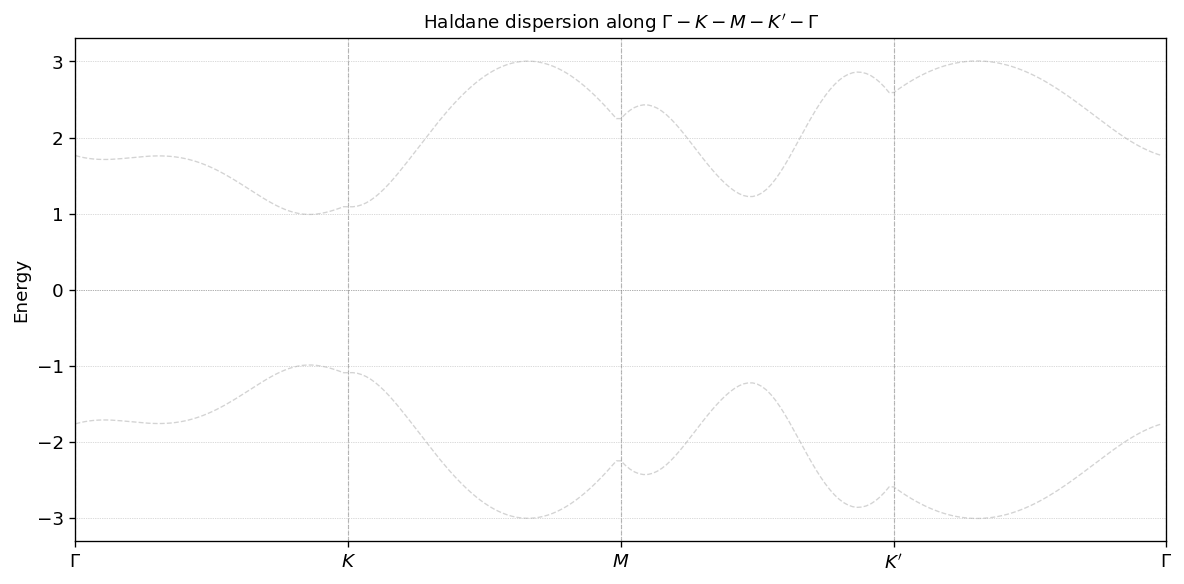

In [10]:
# High-symmetry path dispersion as A(t) evolves

def make_hs_path(n_per=80):
    """Γ→K→M→K'→Γ path."""
    segs = [(G_pt, K_pt), (K_pt, M_pt), (M_pt, Kp_pt), (Kp_pt, G_pt)]
    pts_list, ticks, labels = [], [0], [r'$\Gamma$']
    for p0, p1 in segs:
        kx_ = np.linspace(p0[0], p1[0], n_per)
        ky_ = np.linspace(p0[1], p1[1], n_per)
        pts_list.append(np.c_[kx_, ky_])
        ticks.append(ticks[-1] + n_per)
    # FIX: Use raw strings and explicit prime if necessary, though r"$K'$" is standard
    labels += [r'$K$', r'$M$', r"$K'$", r'$\Gamma$']
    return np.vstack(pts_list), ticks, labels

path_pts, path_ticks, path_labels = make_hs_path(60)
n_path = len(path_pts)

n_gif_disp = 50
t_gif_disp = np.linspace(0, T_per, n_gif_disp, endpoint=False)
Ax_gif_d   = (F0/omega)*np.cos(omega*t_gif_disp)
Ay_gif_d   = (F0/omega)*np.sin(omega*t_gif_disp)

print("Pre-computing dispersion along path ...")
E_path_gif = np.zeros((n_gif_disp, n_path, 2))
for f in range(n_gif_disp):
    for pi_, kpt in enumerate(path_pts):
        E_path_gif[f, pi_] = np.linalg.eigvalsh(
            haldane_bloch_2x2(*kpt, Ax=Ax_gif_d[f], Ay=Ay_gif_d[f]))

E_lim_disp = np.abs(E_path_gif).max() * 1.1

fig_dp, ax_dp = plt.subplots(figsize=(10, 5))
ax_dp.set_xlim(0, n_path)
ax_dp.set_ylim(-E_lim_disp, E_lim_disp)
ax_dp.axhline(0, color='gray', lw=0.4, ls=':')
for t in path_ticks:
    ax_dp.axvline(t, color='gray', lw=0.7, ls='--', alpha=0.5)

ax_dp.set_xticks(path_ticks)
# Ensure labels are passed as raw strings if they contain special chars
ax_dp.set_xticklabels(path_labels, fontsize=11)
ax_dp.set_ylabel('Energy', fontsize=11)
ax_dp.set_title(r'Haldane dispersion along $\Gamma-K-M-K^\prime-\Gamma$', fontsize=11)

# A=0 ghost
for b in range(2):
    ax_dp.plot(E_path_gif[0,:,b], color='lightgray', lw=0.8, ls='--', zorder=1)

line_dp_m, = ax_dp.plot([], [], color='navy',    lw=2.0, zorder=3)
line_dp_p, = ax_dp.plot([], [], color='darkred', lw=2.0, zorder=3, alpha=0.6)
txt_dp = ax_dp.text(0.02, 0.94, '', transform=ax_dp.transAxes,
                     fontsize=9, bbox=dict(fc='white', alpha=0.8, pad=2))

plt.tight_layout()
plt.show()

Saved → Haldane_dispersion_cycle.gif


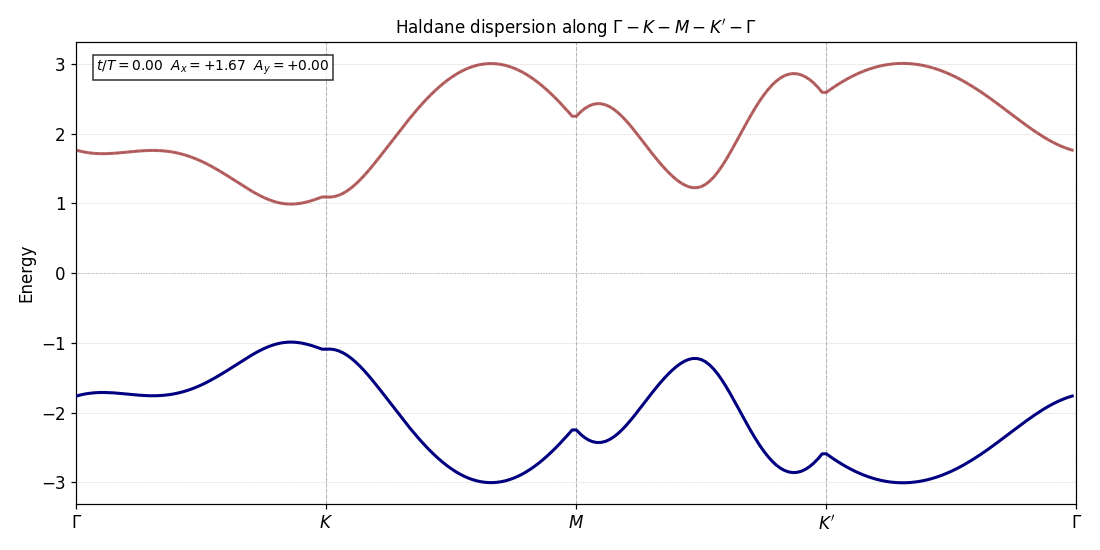

In [11]:
def update_disp_H(frame):
    line_dp_m.set_data(range(n_path), E_path_gif[frame,:,0])
    line_dp_p.set_data(range(n_path), E_path_gif[frame,:,1])
    phase = frame/n_gif_disp
    txt_dp.set_text(fr'$t/T={phase:.2f}$  '
                    fr'$A_x={Ax_gif_d[frame]:+.2f}$  '
                    fr'$A_y={Ay_gif_d[frame]:+.2f}$')
    return line_dp_m, line_dp_p, txt_dp

anim_dp = FuncAnimation(fig_dp, update_disp_H, frames=n_gif_disp,
                         interval=80, blit=False)
anim_dp.save('Haldane_dispersion_cycle.gif',
              writer=PillowWriter(fps=12), dpi=110)
plt.close(fig_dp)
print("Saved → Haldane_dispersion_cycle.gif")
Image('Haldane_dispersion_cycle.gif')

### 10. Gap Closing Conditions vs A

In [12]:
# Monitor gap at K and K' separately during circular drive

n_gif_gap = 60
theta_gap = np.linspace(0, 2*np.pi, n_gif_gap, endpoint=False)
A_circ    = F0/omega

gap_K_gif  = np.zeros(n_gif_gap)
gap_Kp_gif = np.zeros(n_gif_gap)
gap_G_gif  = np.zeros(n_gif_gap)

for f, th in enumerate(theta_gap):
    Ax_v = A_circ*np.cos(th);  Ay_v = A_circ*np.sin(th)
    ev_K  = np.linalg.eigvalsh(haldane_bloch_2x2(*K_pt,  Ax=Ax_v, Ay=Ay_v))
    ev_Kp = np.linalg.eigvalsh(haldane_bloch_2x2(*Kp_pt, Ax=Ax_v, Ay=Ay_v))
    ev_G  = np.linalg.eigvalsh(haldane_bloch_2x2(*G_pt,  Ax=Ax_v, Ay=Ay_v))
    gap_K_gif[f]  = ev_K[1]  - ev_K[0]
    gap_Kp_gif[f] = ev_Kp[1] - ev_Kp[0]
    gap_G_gif[f]  = ev_G[1]  - ev_G[0]

# Also compute 2D minimum gap map at two representative phases
Nk_gm = 50
kx_gm = np.linspace(-2*np.pi/np.sqrt(3), 2*np.pi/np.sqrt(3), Nk_gm)
ky_gm = np.linspace(-np.pi, np.pi, Nk_gm)
KX_gm, KY_gm = np.meshgrid(kx_gm, ky_gm)


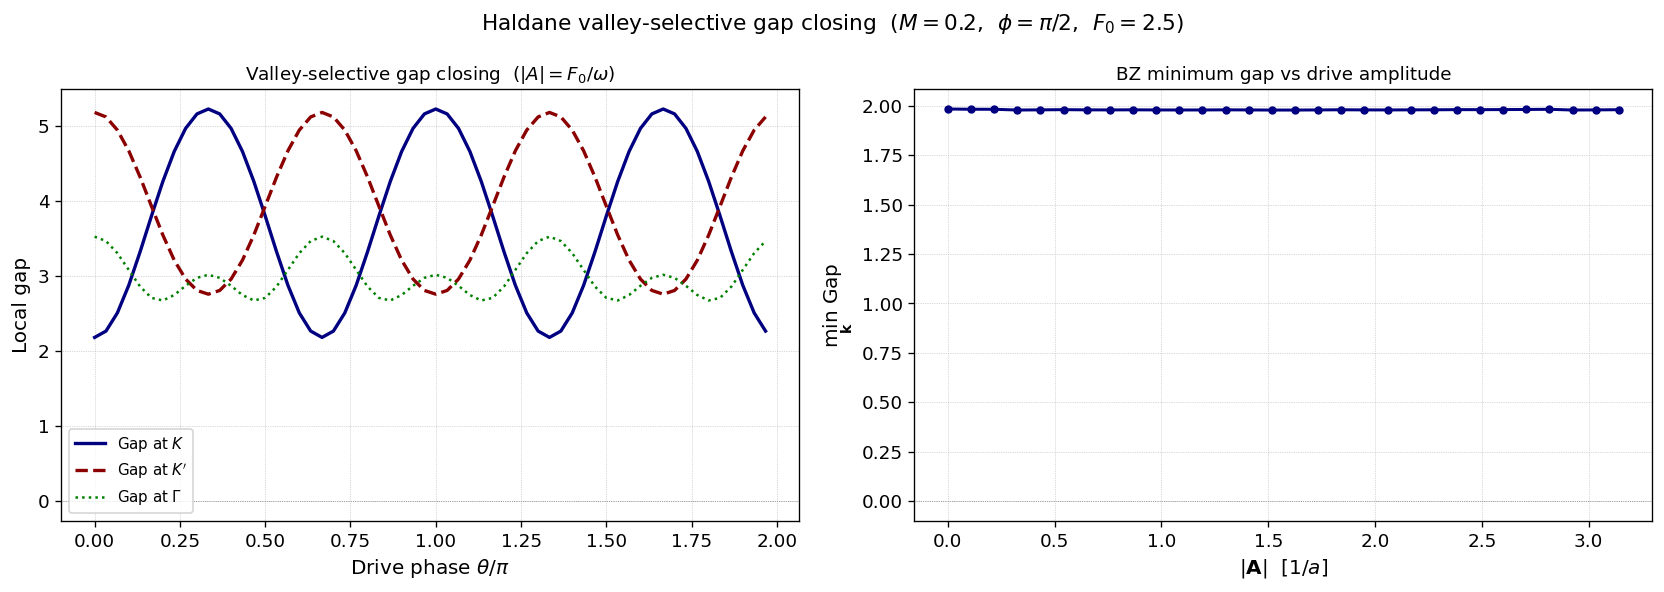

In [13]:
fig_gc, axes_gc = plt.subplots(1, 2, figsize=(14, 5))

# Left: gap at K and K' vs drive phase
ax = axes_gc[0]
ax.plot(theta_gap/np.pi, gap_K_gif,  color='navy',    lw=2.0, label=r'Gap at $K$')
ax.plot(theta_gap/np.pi, gap_Kp_gif, color='darkred', lw=2.0, ls='--', label=r"Gap at $K'$")
ax.plot(theta_gap/np.pi, gap_G_gif,  color='green',   lw=1.5, ls=':', label=r'Gap at $\Gamma$')
ax.axhline(0, color='gray', lw=0.5, ls=':')
ax.set_xlabel(r'Drive phase $\theta/\pi$', fontsize=12)
ax.set_ylabel('Local gap',                 fontsize=12)
ax.set_title(r'Valley-selective gap closing  ($|A|=F_0/\omega$)', fontsize=11)
ax.legend(fontsize=9)

# Right: minimum gap over BZ vs A magnitude
A_mag_scan = np.linspace(0, np.pi, 30)
gap_min_BZ = []
for A_mag in A_mag_scan:
    Ax_v = A_mag*np.cos(np.pi/4);  Ay_v = A_mag*np.sin(np.pi/4)
    gaps = np.zeros((Nk_gm, Nk_gm))
    for i in range(Nk_gm):
        for j in range(Nk_gm):
            ev = np.linalg.eigvalsh(
                haldane_bloch_2x2(kx_gm[i], ky_gm[j], Ax=Ax_v, Ay=Ay_v))
            gaps[j, i] = ev[1] - ev[0]
    gap_min_BZ.append(gaps.min())

ax2 = axes_gc[1]
ax2.plot(A_mag_scan, gap_min_BZ, 'o-', color='navy', lw=1.8, ms=4)
ax2.axhline(0, color='gray', lw=0.5, ls=':')
ax2.set_xlabel(r'$|\mathbf{A}|$  [$1/a$]', fontsize=12)
ax2.set_ylabel(r'$\min_\mathbf{k}$ Gap',   fontsize=12)
ax2.set_title('BZ minimum gap vs drive amplitude', fontsize=11)

fig_gc.suptitle(
    fr'Haldane valley-selective gap closing  ($M={M_val}$,  $\phi=\pi/2$,  $F_0={F0}$)',
    fontsize=13)
plt.tight_layout()
plt.savefig('Haldane_gap_closing.png', dpi=150, bbox_inches='tight')
plt.show()

### 11. Dirac Cone Evolution at K/K' vs A

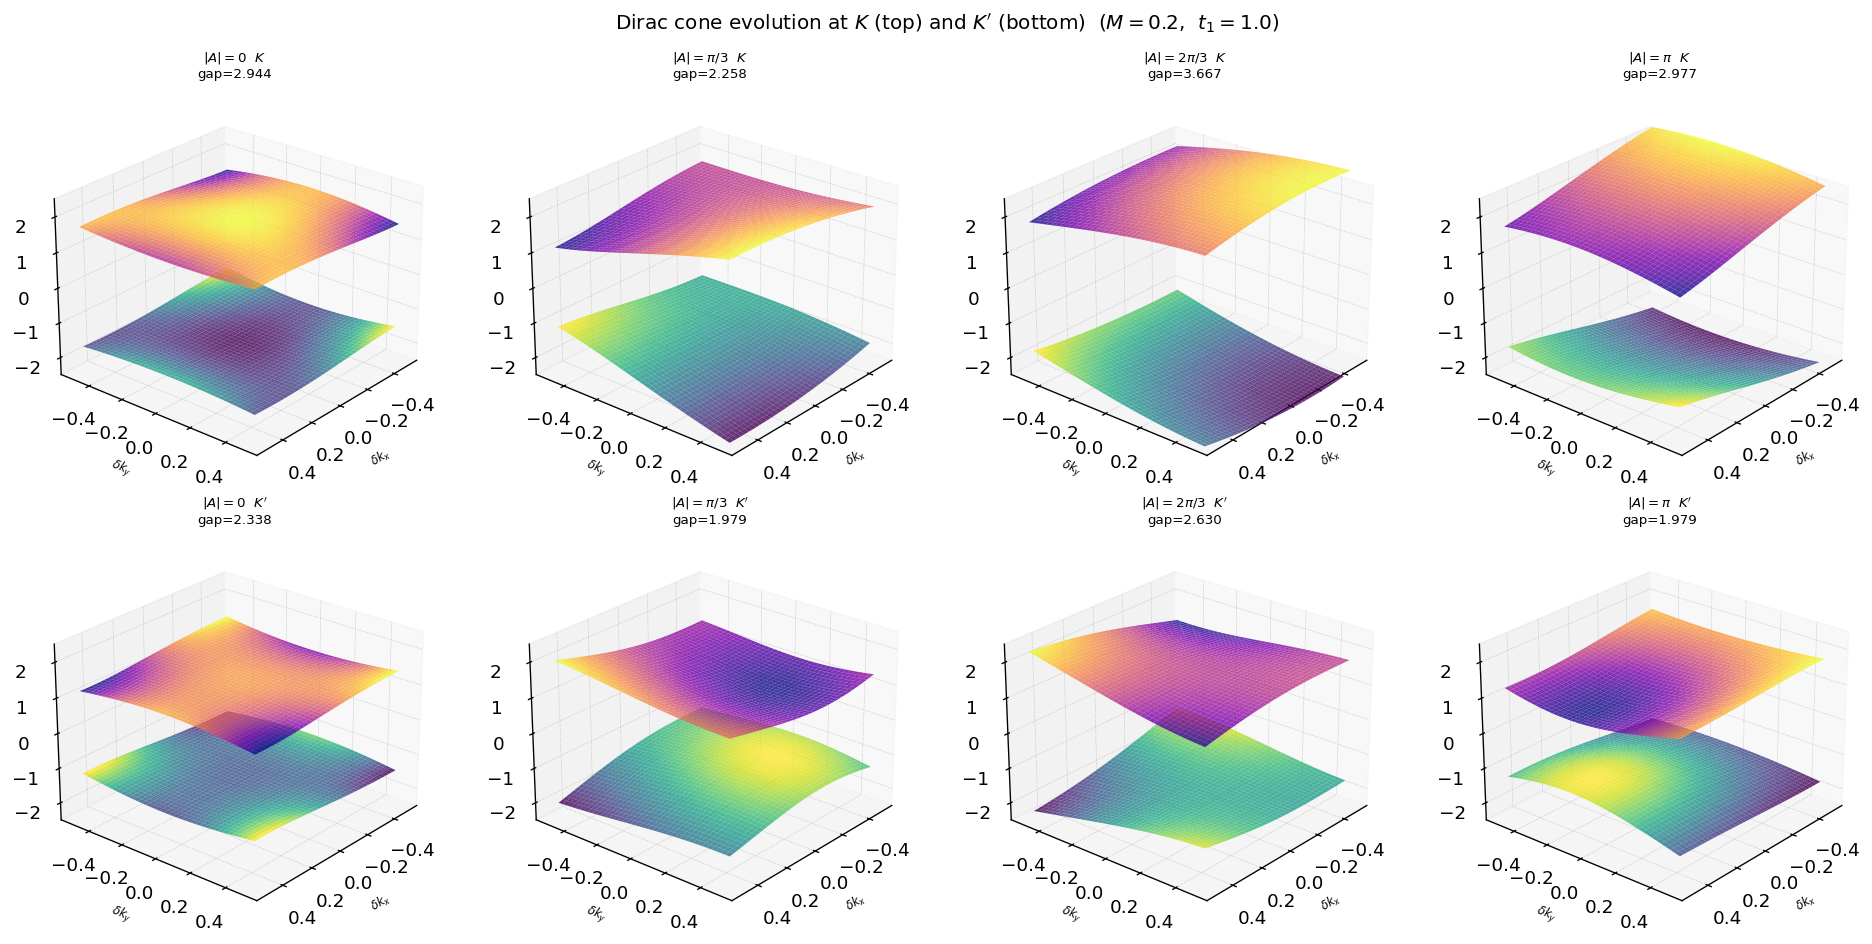

In [14]:
# Zoomed dispersion near K and K' — 3D cone plots

dkx = np.linspace(-0.5, 0.5, 40)
dky = np.linspace(-0.5, 0.5, 40)
DKX, DKY = np.meshgrid(dkx, dky)

A_cone_vals = [0.0, np.pi/3, 2*np.pi/3, np.pi]
A_cone_lbls = ['$|A|=0$', r'$|A|=\pi/3$', r'$|A|=2\pi/3$', r'$|A|=\pi$']

fig_cone = plt.figure(figsize=(16, 8))

# FIX: Use r'$K^\prime$' instead of "K'" to avoid mathtext parser errors
for row_idx, (K_ctr, valley) in enumerate([(K_pt, r'$K$'), (Kp_pt, r'$K^\prime$')]):
    for col_idx, (A_mag, lbl) in enumerate(zip(A_cone_vals, A_cone_lbls)):
        Ax_v = A_mag * np.cos(np.pi/4);  Ay_v = A_mag * np.sin(np.pi/4)
        
        E_cone = np.zeros((40, 40, 2))
        for i in range(40):
            for j in range(40):
                kx_v = K_ctr[0] + dkx[i]
                ky_v = K_ctr[1] + dky[j]
                E_cone[j, i] = np.linalg.eigvalsh(
                    haldane_bloch_2x2(kx_v, ky_v, Ax=Ax_v, Ay=Ay_v))
        gap_local = (E_cone[:,:,1] - E_cone[:,:,0]).min()

        ax3d = fig_cone.add_subplot(2, 4, row_idx*4 + col_idx+1,
                                     projection='3d')
        ax3d.plot_surface(DKX, DKY,  E_cone[:,:,1], cmap='plasma',
                          alpha=0.8, linewidth=0)
        ax3d.plot_surface(DKX, DKY,  E_cone[:,:,0], cmap='viridis',
                          alpha=0.8, linewidth=0)
        
        # FIX: Title now uses the safe valley string
        ax3d.set_title(fr'{lbl}  {valley}''\n'fr'gap={gap_local:.3f}',
                       fontsize=8)
        ax3d.set_xlabel(r'$\delta k_x$', fontsize=7)
        ax3d.set_ylabel(r'$\delta k_y$', fontsize=7)
        ax3d.view_init(elev=25, azim=40)
        ax3d.set_zlim(-2.5, 2.5)

# FIX: Use raw string with ^\prime for the suptitle to avoid parser issues
fig_cone.suptitle(
    r'Dirac cone evolution at $K$ (top) and $K^\prime$ (bottom)  '
    fr'($M={M_val}$,  $t_1={t1_val}$)',
    fontsize=12)

plt.tight_layout()
plt.savefig('Haldane_dirac_cones.png', dpi=150, bbox_inches='tight')
plt.show()

### 12. Haldane Band Structure vs A

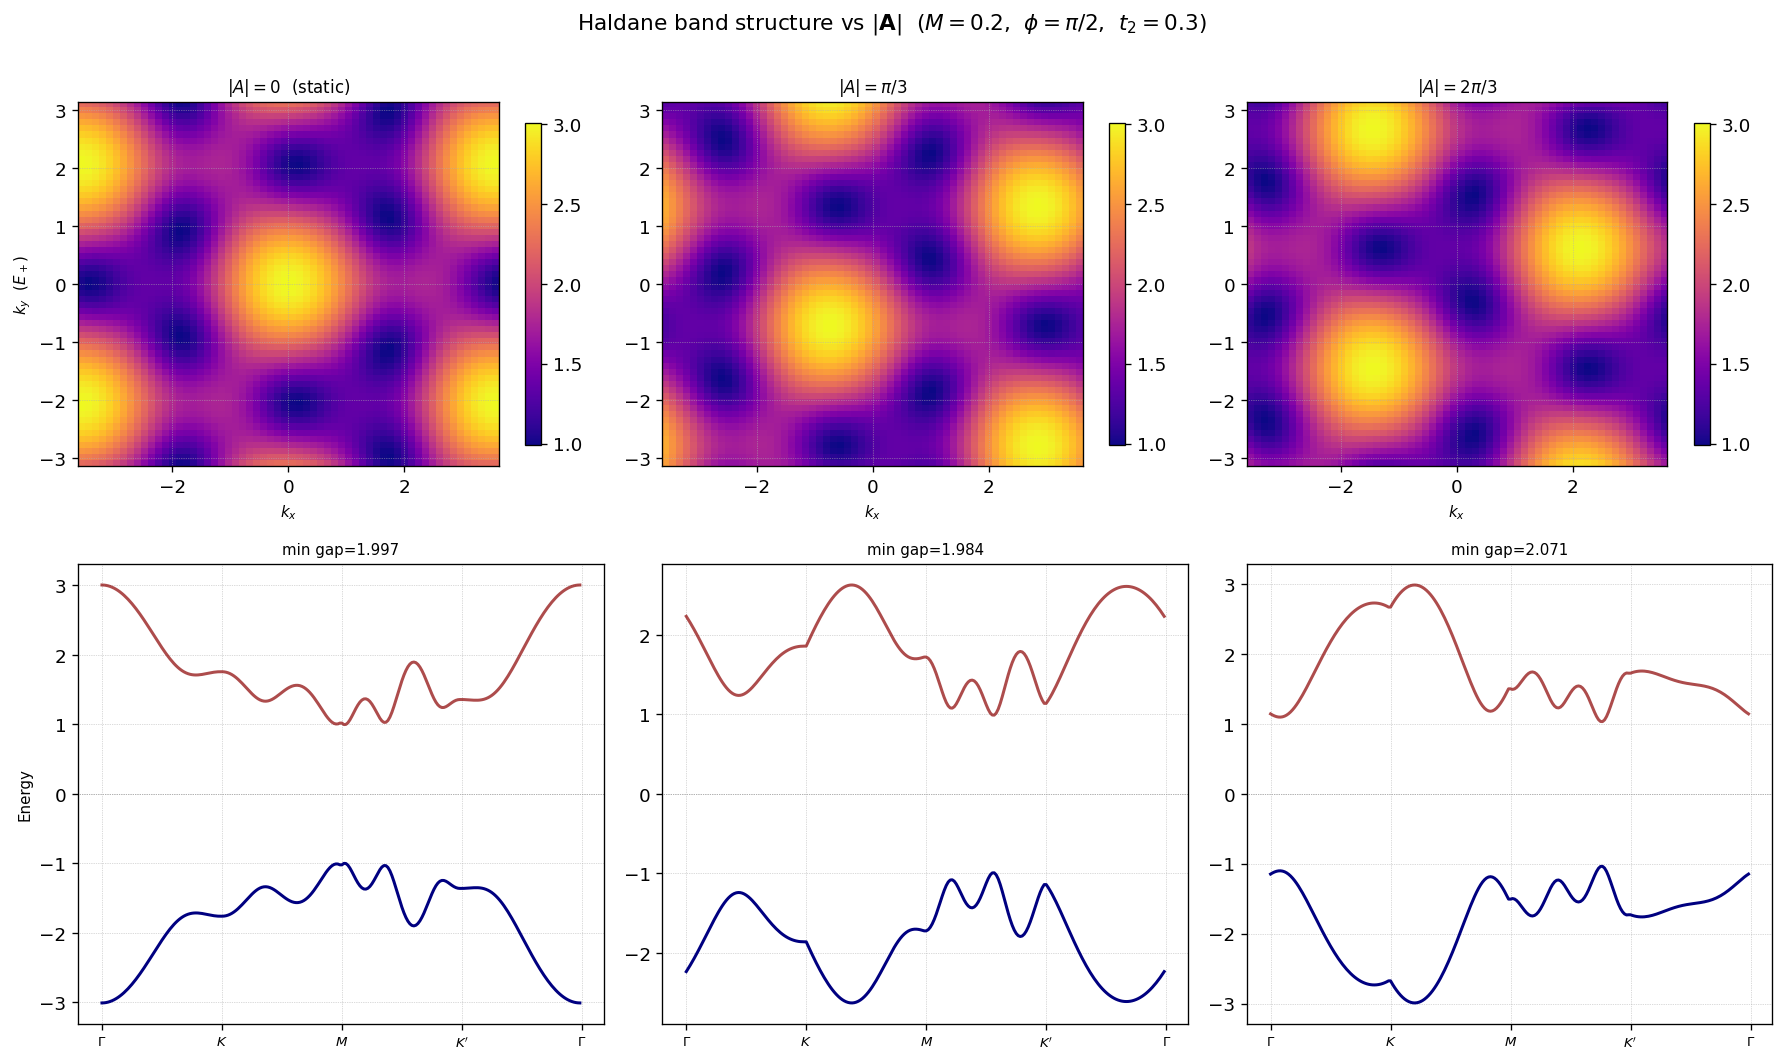

In [15]:
# 2D band map + edge state structure at representative A values

Nk_bm = 60
kx_bm = np.linspace(-2*np.pi/np.sqrt(3), 2*np.pi/np.sqrt(3), Nk_bm)
ky_bm = np.linspace(-np.pi, np.pi, Nk_bm)
KX_bm, KY_bm = np.meshgrid(kx_bm, ky_bm)

A_bm_vals = [0.0, np.pi/3, 2*np.pi/3]
A_bm_lbls = ['$|A|=0$  (static)', r'$|A|=\pi/3$', r'$|A|=2\pi/3$']

fig_bm, axes_bm = plt.subplots(2, 3, figsize=(15, 9))
for col, (A_mag, lbl) in enumerate(zip(A_bm_vals, A_bm_lbls)):
    Ax_v = A_mag*np.cos(np.pi/4);  Ay_v = A_mag*np.sin(np.pi/4)
    Ep = np.zeros((Nk_bm, Nk_bm))
    for i in range(Nk_bm):
        for j in range(Nk_bm):
            ev = np.linalg.eigvalsh(
                haldane_bloch_2x2(kx_bm[j], ky_bm[i], Ax=Ax_v, Ay=Ay_v))
            Ep[i, j] = ev[1]

    im = axes_bm[0, col].imshow(Ep, origin='lower',
                                  extent=[-2*np.pi/np.sqrt(3),
                                           2*np.pi/np.sqrt(3),
                                           -np.pi, np.pi],
                                  cmap='plasma', aspect='equal')
    axes_bm[0, col].set_title(lbl, fontsize=10)
    axes_bm[0, col].set_xlabel(r'$k_x$', fontsize=9)
    if col == 0:
        axes_bm[0, col].set_ylabel(r'$k_y$  ($E_+$)', fontsize=9)
    plt.colorbar(im, ax=axes_bm[0,col], shrink=0.7)

    # Band along Γ→K→M→K'→Γ
    E_p_arr = np.array([np.linalg.eigvalsh(
        haldane_bloch_2x2(*kpt, Ax=Ax_v, Ay=Ay_v))
        for kpt in path_pts])
    axes_bm[1, col].plot(E_p_arr[:,0], color='navy',    lw=1.8)
    axes_bm[1, col].plot(E_p_arr[:,1], color='darkred', lw=1.8, alpha=0.7)
    axes_bm[1, col].axhline(0, color='gray', lw=0.4, ls=':')
    axes_bm[1, col].set_xticks(path_ticks)
    axes_bm[1, col].set_xticklabels(path_labels, fontsize=8)
    gap_bm = (E_p_arr[:,1] - E_p_arr[:,0]).min()
    axes_bm[1, col].set_title(fr'min gap={gap_bm:.3f}', fontsize=9)
    if col == 0:
        axes_bm[1, col].set_ylabel('Energy', fontsize=9)

fig_bm.suptitle(
    fr'Haldane band structure vs $|\mathbf{{A}}|$  '
    fr'($M={M_val}$,  $\phi=\pi/2$,  $t_2={t2_val}$)',
    fontsize=13)
plt.tight_layout()
plt.savefig('Haldane_bandstructure_vs_A.png', dpi=150, bbox_inches='tight')
plt.show()

### 13. Chern Number vs (M, φ) as A Changes

In [16]:
# Fukui Chern number for Haldane

def haldane_chern_fukui(M=M_val, t1=t1_val, t2=t2_val,
                         phi=phi_val, Ax=0.0, Ay=0.0, Nk=30):
    """Chern number via Fukui method for Haldane model."""
    kx_ = np.linspace(-2*np.pi/np.sqrt(3), 2*np.pi/np.sqrt(3),
                       Nk, endpoint=False)
    ky_ = np.linspace(-np.pi, np.pi, Nk, endpoint=False)

    u = np.zeros((Nk, Nk, 2), dtype=complex)
    for i in range(Nk):
        for j in range(Nk):
            _, evecs = np.linalg.eigh(
                haldane_bloch_2x2(kx_[i], ky_[j], M, t1, t2, phi, Ax, Ay))
            u[i, j] = evecs[:, 0]

    C = 0.0
    for i in range(Nk):
        for j in range(Nk):
            i1, j1 = (i+1)%Nk, (j+1)%Nk
            link = ((np.conj(u[i,j])   @ u[i1,j ])  *
                    (np.conj(u[i1,j])  @ u[i1,j1]) *
                    (np.conj(u[i1,j1]) @ u[i, j1]) *
                    (np.conj(u[i,j1])  @ u[i, j ]))
            C += np.angle(link)
    return int(np.round(C / (2*np.pi)))


# Phase diagram (M/t2, phi) at several |A| values
n_M   = 20
n_phi = 20
M_pd  = np.linspace(-5.0, 5.0, n_M)    # M/t2
phi_pd = np.linspace(0, 2*np.pi, n_phi)
A_pd_vals = [0.0, np.pi/4, np.pi/2, np.pi]

print("Computing Chern phase diagram for animation ...")
C_pd_data = np.zeros((len(A_pd_vals), n_M, n_phi), dtype=int)
for ai, A_mag in enumerate(A_pd_vals):
    Ax_v = A_mag*np.cos(np.pi/4);  Ay_v = A_mag*np.sin(np.pi/4)
    for mi, Mval in enumerate(M_pd):
        for pi_, phiv in enumerate(phi_pd):
            C_pd_data[ai, mi, pi_] = haldane_chern_fukui(
                M=Mval*t2_val, phi=phiv, Ax=Ax_v, Ay=Ay_v, Nk=20)
    print(f"  |A|={A_mag:.2f}  done")
print("Done.")

Computing Chern phase diagram for animation ...
  |A|=0.00  done
  |A|=0.79  done
  |A|=1.57  done
  |A|=3.14  done
Done.


/tmp/ipykernel_58/3637657347.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_C = plt.cm.get_cmap('RdYlBu', 3)


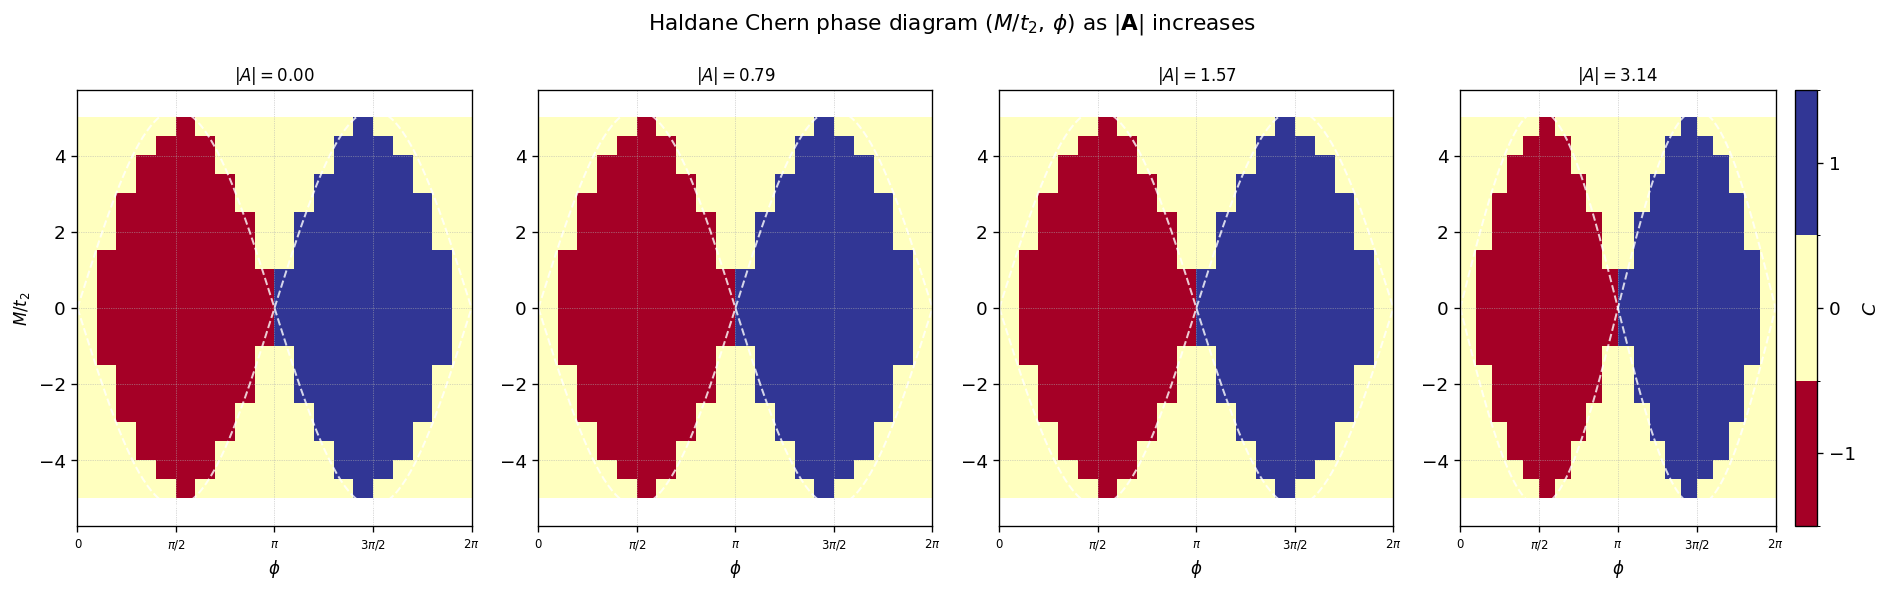

In [17]:
cmap_C = plt.cm.get_cmap('RdYlBu', 3)
norm_C = BoundaryNorm([-1.5,-0.5,0.5,1.5], cmap_C.N)

fig_pd, axes_pd = plt.subplots(1, 4, figsize=(16, 5))
for ai, (ax_pd, A_mag) in enumerate(zip(axes_pd, A_pd_vals)):
    im_pd = ax_pd.imshow(C_pd_data[ai], origin='lower', aspect='auto',
                          extent=[0, 2*np.pi, M_pd[0], M_pd[-1]],
                          cmap=cmap_C, norm=norm_C)
    # Static phase boundaries
    phi_arr = np.linspace(0, 2*np.pi, 200)
    ax_pd.plot(phi_arr,  3*np.sqrt(3)*np.sin(phi_arr), 'w--', lw=1.2, alpha=0.8)
    ax_pd.plot(phi_arr, -3*np.sqrt(3)*np.sin(phi_arr), 'w--', lw=1.2, alpha=0.8)
    ax_pd.set_xlabel(r'$\phi$', fontsize=10)
    if ai == 0:
        ax_pd.set_ylabel(r'$M/t_2$', fontsize=10)
    ax_pd.set_title(fr'$|A|={A_mag:.2f}$', fontsize=10)
    ax_pd.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
    ax_pd.set_xticklabels(['0',r'$\pi/2$',r'$\pi$',r'$3\pi/2$',r'$2\pi$'],
                           fontsize=7)

plt.colorbar(im_pd, ax=axes_pd[-1], label='$C$', ticks=[-1,0,1])
fig_pd.suptitle(
    r'Haldane Chern phase diagram $(M/t_2,\,\phi)$ as $|\mathbf{A}|$ increases',
    fontsize=13)
plt.tight_layout()
plt.savefig('Haldane_chern_phase_diagram.png', dpi=150, bbox_inches='tight')
plt.show()

## Floquet Analysis

### 14. Floquet Spectrum vs Drive Amplitude

In [18]:
# Floquet propagator — batched over k-grid

Nk_fl     = 20
kx_fl_arr = np.linspace(-2*np.pi/np.sqrt(3), 2*np.pi/np.sqrt(3),
                         Nk_fl, endpoint=False)
ky_fl_arr = np.linspace(-np.pi, np.pi, Nk_fl, endpoint=False)
KX_fl, KY_fl = np.meshgrid(kx_fl_arr, ky_fl_arr, indexing='ij')
n_steps_fl = 100


def floquet_propagator_H_batch(M=M_val, t1=t1_val, t2=t2_val,
                                 phi=phi_val, F0_val=F0,
                                 n_steps=n_steps_fl):
    """Batched Floquet U_F(k) over Nk×Nk BZ grid."""
    T     = 2*np.pi/omega
    dt_f  = T/n_steps
    t_f   = np.linspace(0, T, n_steps, endpoint=False)
    Ax_f  = (F0_val/omega)*np.cos(omega*t_f)
    Ay_f  = (F0_val/omega)*np.sin(omega*t_f)

    U = np.zeros((Nk_fl, Nk_fl, 2, 2), dtype=complex)
    U[:,:,0,0] = 1.0;  U[:,:,1,1] = 1.0

    def H_batch(Ax, Ay):
        H = np.zeros((Nk_fl, Nk_fl, 2, 2), dtype=complex)
        for i in range(Nk_fl):
            for j in range(Nk_fl):
                H[i,j] = haldane_bloch_2x2(
                    KX_fl[i,j], KY_fl[i,j], M, t1, t2, phi, Ax, Ay)
        return H

    def f(u, Ax, Ay):
        H = H_batch(Ax, Ay)
        return -1j * np.einsum('xyij,xyjl->xyil', H, u)

    for step in range(n_steps):
        t_mid   = t_f[step] + 0.5*dt_f
        Ax_mid  = (F0_val/omega)*np.cos(omega*t_mid)
        Ay_mid  = (F0_val/omega)*np.sin(omega*t_mid)
        Ax_next = (F0_val/omega)*np.cos(omega*(t_f[step]+dt_f))
        Ay_next = (F0_val/omega)*np.sin(omega*(t_f[step]+dt_f))
        k1 = f(U,             Ax_f[step], Ay_f[step])
        k2 = f(U+0.5*dt_f*k1, Ax_mid,    Ay_mid)
        k3 = f(U+0.5*dt_f*k2, Ax_mid,    Ay_mid)
        k4 = f(U+    dt_f*k3, Ax_next,   Ay_next)
        U  = U + (dt_f/6.0)*(k1+2*k2+2*k3+k4)
    return U

def haldane_static_chern_analytic(M, t1, t2, phi):
    """Analytic Chern number for Haldane at zero field."""
    M_crit = 3 * np.sqrt(3) * t2 * abs(np.sin(phi))
    if abs(M) > M_crit:
        return 0
    elif M > 0:
        return 1
    elif M < 0:
        return -1
    else:
        return 0

In [19]:
def floquet_chern_H(M=M_val, F0_val=F0, Nk=80, n_steps=150,
                     static_at_zero=True):
    """
    Floquet Chern number for Haldane model with continuity tracking.
    Uses overlap with previous k-point to maintain band continuity.
    Returns integer Chern number or np.nan if gap is too small.
    """
    # --- Static fallback at zero drive ---
    if static_at_zero and np.isclose(F0_val, 0.0, atol=1e-8):
        return haldane_static_chern_analytic(M=M, t1=t1_val, t2=t2_val,
                                    phi=phi_val)

    # Create k-grid
    kx = np.linspace(-2*np.pi/np.sqrt(3), 2*np.pi/np.sqrt(3), Nk, endpoint=False)
    ky = np.linspace(-np.pi, np.pi, Nk, endpoint=False)
    KX, KY = np.meshgrid(kx, ky, indexing='ij')

    # ---------- Build Floquet propagator U ----------
    def build_H_batch(Ax, Ay):
        H = np.zeros((Nk, Nk, 2, 2), dtype=complex)
        for i in range(Nk):
            for j in range(Nk):
                H[i, j] = haldane_bloch_2x2(KX[i,j], KY[i,j], M,
                                             t1_val, t2_val, phi_val, Ax, Ay)
        return H

    def f(u, Ax, Ay):
        H = build_H_batch(Ax, Ay)
        return -1j * np.einsum('xyij,xyjl->xyil', H, u)

    T = 2 * np.pi / omega
    dt_f = T / n_steps
    t_f = np.linspace(0, T, n_steps, endpoint=False)
    Ax_f = (F0_val / omega) * np.cos(omega * t_f)
    Ay_f = (F0_val / omega) * np.sin(omega * t_f)

    U = np.eye(2, dtype=complex)[None, None, :, :] * np.ones((Nk, Nk, 1, 1))
    U = U.astype(complex)

    for step in range(n_steps):
        t_mid = t_f[step] + 0.5 * dt_f
        Ax_mid = (F0_val / omega) * np.cos(omega * t_mid)
        Ay_mid = (F0_val / omega) * np.sin(omega * t_mid)
        Ax_next = (F0_val / omega) * np.cos(omega * (t_f[step] + dt_f))
        Ay_next = (F0_val / omega) * np.sin(omega * (t_f[step] + dt_f))

        k1 = f(U, Ax_f[step], Ay_f[step])
        k2 = f(U + 0.5 * dt_f * k1, Ax_mid, Ay_mid)
        k3 = f(U + 0.5 * dt_f * k2, Ax_mid, Ay_mid)
        k4 = f(U + dt_f * k3, Ax_next, Ay_next)
        U = U + (dt_f / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

    # ---------- Extract eigenvectors with ADIABATIC tracking ----------
    u = np.zeros((Nk, Nk, 2), dtype=complex)
    gap_min = np.inf

    # Step 1: Pick reference band at (0,0) using quasi-energy sorting
    evals_00, evecs_00 = np.linalg.eig(U[0, 0])
    qe_00 = -np.angle(evals_00) / T
    idx_00 = np.argsort(qe_00.real)
    u[0, 0] = evecs_00[:, idx_00[0]]  # Lower quasi-energy at origin

    # Step 2: Sweep along x-direction first
    for i in range(1, Nk):
        evals, evecs = np.linalg.eig(U[i, 0])
        qe = -np.angle(evals) / T
        # Choose band with max overlap with PREVIOUS k-point
        ov = np.array([np.abs(np.vdot(u[i-1, 0], evecs[:, m]))**2 
                       for m in range(2)])
        chosen = np.argmax(ov)
        u[i, 0] = evecs[:, chosen]
        gap = abs(qe[np.argsort(qe.real)[1]] - qe[np.argsort(qe.real)[0]])
        gap_min = min(gap_min, gap)

    # Step 3: Sweep along y-direction for each x
    for i in range(Nk):
        for j in range(1, Nk):
            evals, evecs = np.linalg.eig(U[i, j])
            qe = -np.angle(evals) / T
            # Max overlap with neighbor in y-direction
            ov = np.array([np.abs(np.vdot(u[i, j-1], evecs[:, m]))**2 
                           for m in range(2)])
            chosen = np.argmax(ov)
            u[i, j] = evecs[:, chosen]
            gap = abs(qe[np.argsort(qe.real)[1]] - qe[np.argsort(qe.real)[0]])
            gap_min = min(gap_min, gap)

    # Check gap validity
    if gap_min < 1e-4:  # Relaxed threshold; Fukui handles small gaps better than sorting
        print(f"Warning: Small gap {gap_min:.2e} at F0={F0_val}")
        # Don't return NaN; let Fukui decide. Only reject if truly gapless.

    # ---------- Fukui plaquette sum ----------
    C = 0.0
    for i in range(Nk):
        for j in range(Nk):
            i1 = (i + 1) % Nk
            j1 = (j + 1) % Nk
            link = ((np.conj(u[i, j])   @ u[i1, j ]) *
                    (np.conj(u[i1, j])  @ u[i1, j1]) *
                    (np.conj(u[i1, j1]) @ u[i, j1 ]) *
                    (np.conj(u[i, j1])  @ u[i, j  ]))
            C += np.angle(link)

    return int(np.round(C / (2 * np.pi)))

Computing Floquet quasi-energy spectra ...


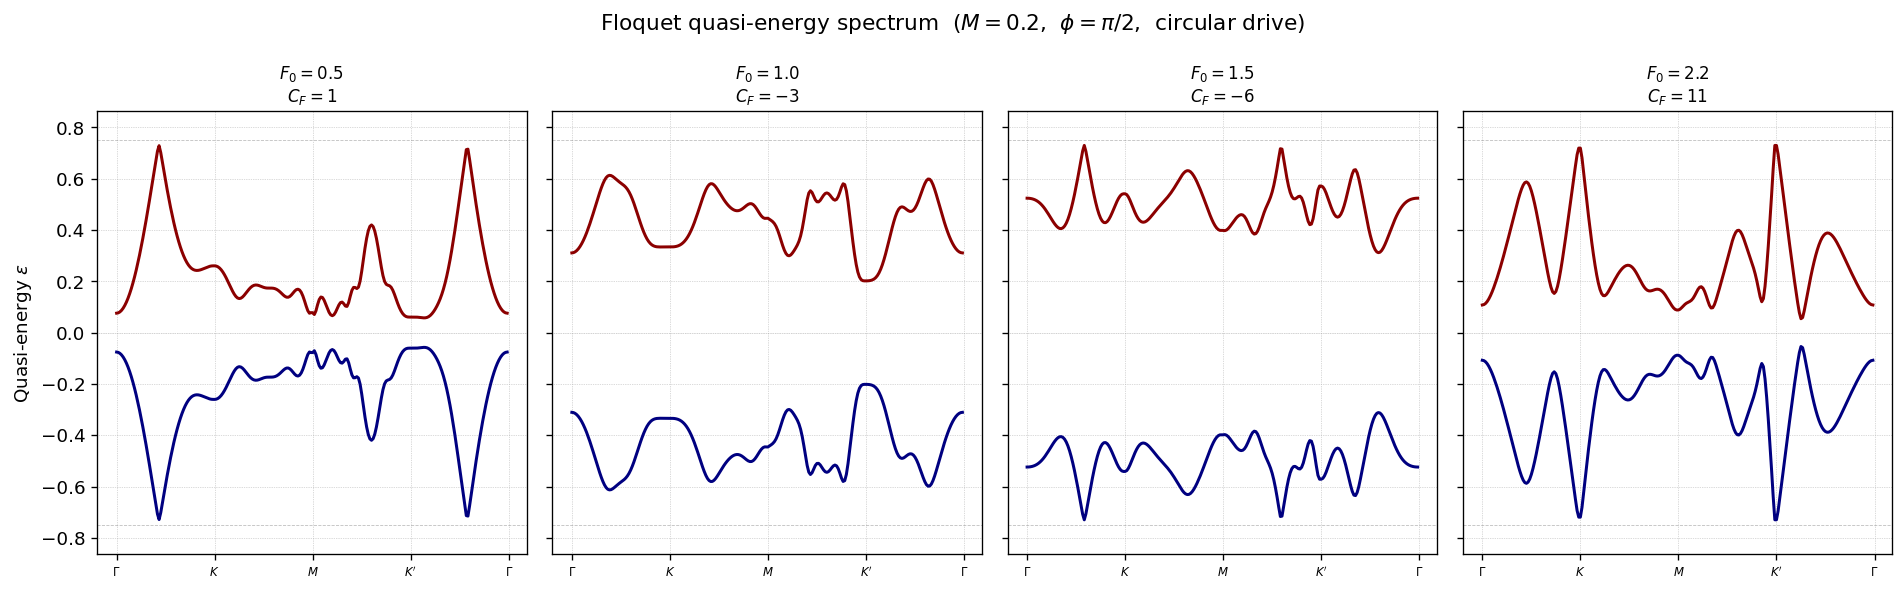

In [20]:
# Floquet spectrum along path at 4 F0 values
F0_show_fl = [0.5, 1.0, 1.5, 2.2]
T_laser    = 2*np.pi/omega
qe_lim     = np.pi/T_laser * 1.15

print("Computing Floquet quasi-energy spectra ...")
fig_fl, axes_fl = plt.subplots(1, 4, figsize=(16, 5), sharey=True)

for ax, F0v in zip(axes_fl, F0_show_fl):
    qe_all = np.zeros((len(path_pts), 2))
    for pi_, kpt in enumerate(path_pts):
        T    = 2*np.pi/omega
        dt_p = T/80
        t_p  = np.linspace(0, T, 80, endpoint=False)
        U_k  = np.eye(2, dtype=complex)
        for step in range(80):
            Ax = (F0v/omega)*np.cos(omega*t_p[step])
            Ay = (F0v/omega)*np.sin(omega*t_p[step])
            H  = haldane_bloch_2x2(*kpt, Ax=Ax, Ay=Ay)
            t_m= t_p[step]+0.5*dt_p
            Hm = haldane_bloch_2x2(*kpt,
                                    Ax=(F0v/omega)*np.cos(omega*t_m),
                                    Ay=(F0v/omega)*np.sin(omega*t_m))
            k1 = -1j*H  @ U_k
            k2 = -1j*Hm @ (U_k+0.5*dt_p*k1)
            k3 = -1j*Hm @ (U_k+0.5*dt_p*k2)
            tn = t_p[step]+dt_p
            Hn = haldane_bloch_2x2(*kpt,
                                    Ax=(F0v/omega)*np.cos(omega*tn),
                                    Ay=(F0v/omega)*np.sin(omega*tn))
            k4 = -1j*Hn @ (U_k+dt_p*k3)
            U_k = U_k + (dt_p/6)*(k1+2*k2+2*k3+k4)
        ev_U = np.linalg.eigvals(U_k)
        qe_all[pi_] = np.sort(-np.angle(ev_U).real/T)

    CF = floquet_chern_H(M_val, F0v, n_steps=60)
    for b in range(2):
        ax.plot(qe_all[:,b], color='navy' if b==0 else 'darkred', lw=1.8)
    ax.axhline( np.pi/T, color='gray', lw=0.5, ls='--', alpha=0.5)
    ax.axhline(-np.pi/T, color='gray', lw=0.5, ls='--', alpha=0.5)
    ax.axhline(0,        color='gray', lw=0.3, ls=':',  alpha=0.4)
    ax.set_xticks(path_ticks)
    ax.set_xticklabels(path_labels, fontsize=7)
    ax.set_title(fr'$F_0={F0v}$''\n'fr'$C_F={CF}$', fontsize=10)
    ax.set_ylim(-qe_lim, qe_lim)

axes_fl[0].set_ylabel(r'Quasi-energy $\varepsilon$', fontsize=11)
fig_fl.suptitle(
    fr'Floquet quasi-energy spectrum  ($M={M_val}$,  $\phi=\pi/2$,  circular drive)',
    fontsize=13)
plt.tight_layout()
plt.savefig('Haldane_floquet_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()

### 15. Floquet Quasi-Energies over One Cycle

Pre-computing instantaneous band surfaces ...


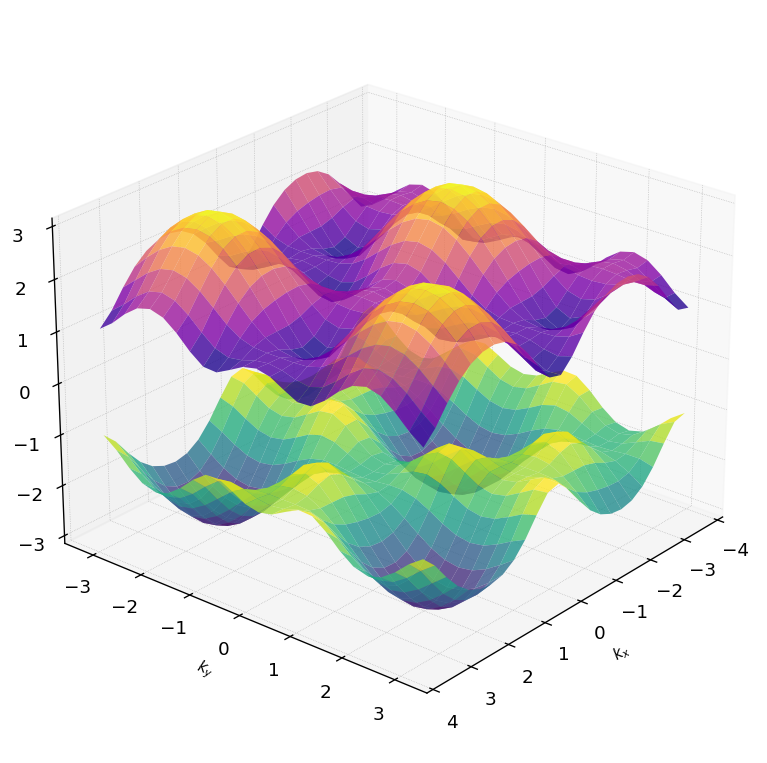

In [21]:
# Instantaneous quasi-energy surface over one laser cycle

n_gif_fl2 = 40
t_fl2     = np.linspace(0, T_per, n_gif_fl2, endpoint=False)
Ax_fl2    = (F0/omega)*np.cos(omega*t_fl2)
Ay_fl2    = (F0/omega)*np.sin(omega*t_fl2)

Nk_sf = 25
kx_sf = np.linspace(-2*np.pi/np.sqrt(3), 2*np.pi/np.sqrt(3), Nk_sf)
ky_sf = np.linspace(-np.pi, np.pi, Nk_sf)
KX_sf, KY_sf = np.meshgrid(kx_sf, ky_sf)

print("Pre-computing instantaneous band surfaces ...")
Ep_sf = np.zeros((n_gif_fl2, Nk_sf, Nk_sf))
for f in range(n_gif_fl2):
    for i in range(Nk_sf):
        for j in range(Nk_sf):
            ev = np.linalg.eigvalsh(
                haldane_bloch_2x2(kx_sf[i], ky_sf[j],
                                   Ax=Ax_fl2[f], Ay=Ay_fl2[f]))
            Ep_sf[f, j, i] = ev[1]

E_sf_lim = Ep_sf.max() * 1.05

fig_sf = plt.figure(figsize=(10, 8))
ax_sf  = fig_sf.add_subplot(111, projection='3d')
surf_p_sf = [ax_sf.plot_surface(KX_sf, KY_sf,  Ep_sf[0],
                                  cmap='plasma', alpha=0.8)]
surf_m_sf = [ax_sf.plot_surface(KX_sf, KY_sf, -Ep_sf[0],
                                  cmap='viridis', alpha=0.8)]
ax_sf.set_xlabel(r'$k_x$', fontsize=9)
ax_sf.set_ylabel(r'$k_y$', fontsize=9)
ax_sf.set_zlabel('$E$',    fontsize=9)
ax_sf.set_zlim(-E_sf_lim, E_sf_lim)
ax_sf.view_init(elev=25, azim=40)
txt_sf = fig_sf.text(0.5, 0.96, '', ha='center', fontsize=11)

Saved → Haldane_floquet_eigenenergies.gif


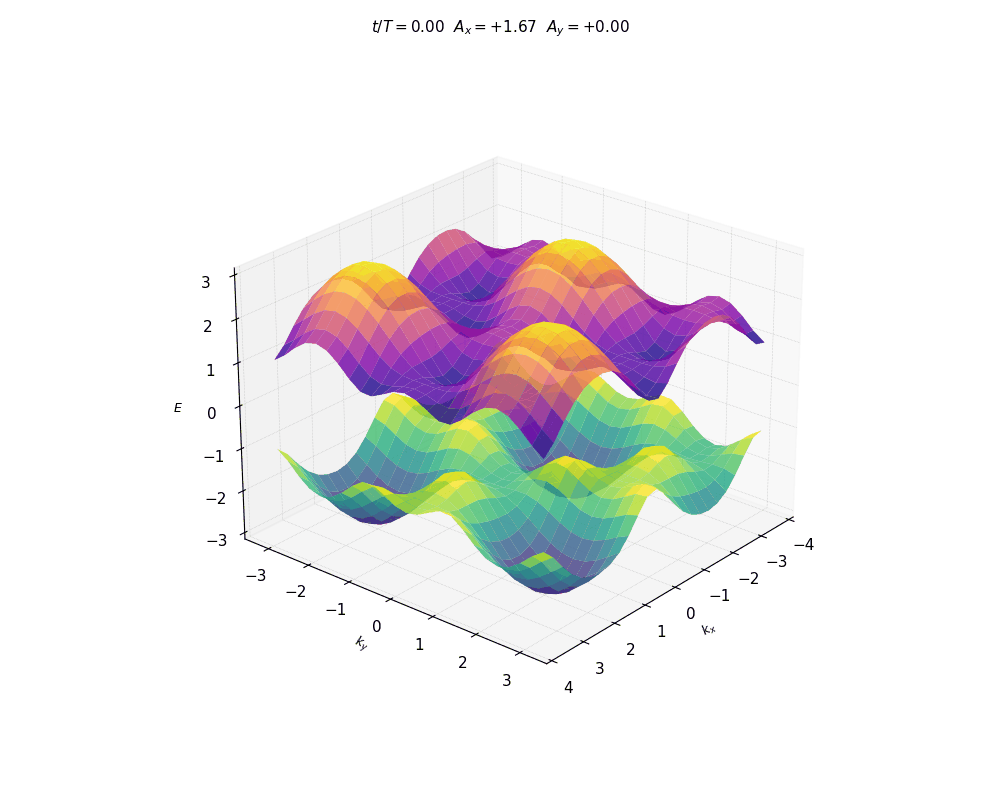

In [22]:
def update_sf(frame):
    surf_p_sf[0].remove();  surf_m_sf[0].remove()
    surf_p_sf[0] = ax_sf.plot_surface(KX_sf, KY_sf,  Ep_sf[frame],
                                       cmap='plasma', alpha=0.8)
    surf_m_sf[0] = ax_sf.plot_surface(KX_sf, KY_sf, -Ep_sf[frame],
                                       cmap='viridis', alpha=0.8)
    ph = frame/n_gif_fl2
    txt_sf.set_text(
        fr'$t/T={ph:.2f}$  $A_x={Ax_fl2[frame]:+.2f}$  $A_y={Ay_fl2[frame]:+.2f}$')
    return surf_p_sf[0], surf_m_sf[0], txt_sf

anim_sf = FuncAnimation(fig_sf, update_sf, frames=n_gif_fl2,
                         interval=120, blit=False)
anim_sf.save('Haldane_floquet_eigenenergies.gif',
              writer=PillowWriter(fps=8), dpi=100)
plt.close(fig_sf)
print("Saved → Haldane_floquet_eigenenergies.gif")
Image('Haldane_floquet_eigenenergies.gif')

### 16. Floquet Chern Number Tracking

In [24]:
# ── Floquet Chern number vs F0 (Haldane) ──────────────────────────────────
F0_chern_scan = np.linspace(0.0, 2.5, 15)
CF_C1, CF_triv, CF_neg = [], [], []

print("Computing Floquet Chern number vs F0 ...")
print(f"{'F0':>6}  {'CF(C=+1)':>10}  {'CF(triv)':>10}  {'CF(C=-1)':>10}")
for F0v in F0_chern_scan:
    c1 = floquet_chern_H(M_val, F0v)      # M = +0.2 → C=+1
    ct = floquet_chern_H(M_triv, F0v)     # M = 4.0  → trivial
    cn = floquet_chern_H(-M_val, F0v)     # M = -0.2 → C=-1
    CF_C1.append(c1)
    CF_triv.append(ct)
    CF_neg.append(cn)
    # Print with handling of NaN values
    c1_str = f"{c1:>10}" if not np.isnan(c1) else "       nan"
    ct_str = f"{ct:>10}" if not np.isnan(ct) else "       nan"
    cn_str = f"{cn:>10}" if not np.isnan(cn) else "       nan"
    print(f"{F0v:6.3f}  {c1_str}  {ct_str}  {cn_str}")

CF_C1, CF_triv, CF_neg = np.array(CF_C1), np.array(CF_triv), np.array(CF_neg)
print("Done.")

Computing Floquet Chern number vs F0 ...
    F0    CF(C=+1)    CF(triv)    CF(C=-1)
 0.000           1           0          -1
 0.179          -2           0          -5
 0.357          -3           0          -3
 0.536           1           0           2
 0.714          -3           0          -3
 0.893          -3          -5          -3
 1.071          -3           0          -3
 1.250         -17          -5         -15
 1.429          -8          -1          -8
 1.607          -3         -14          -3
 1.786          -2         -11          -2
 1.964           0           0           0
 2.143          12           0          13
 2.321           8          12           4
 2.500          -1          11           0
Done.


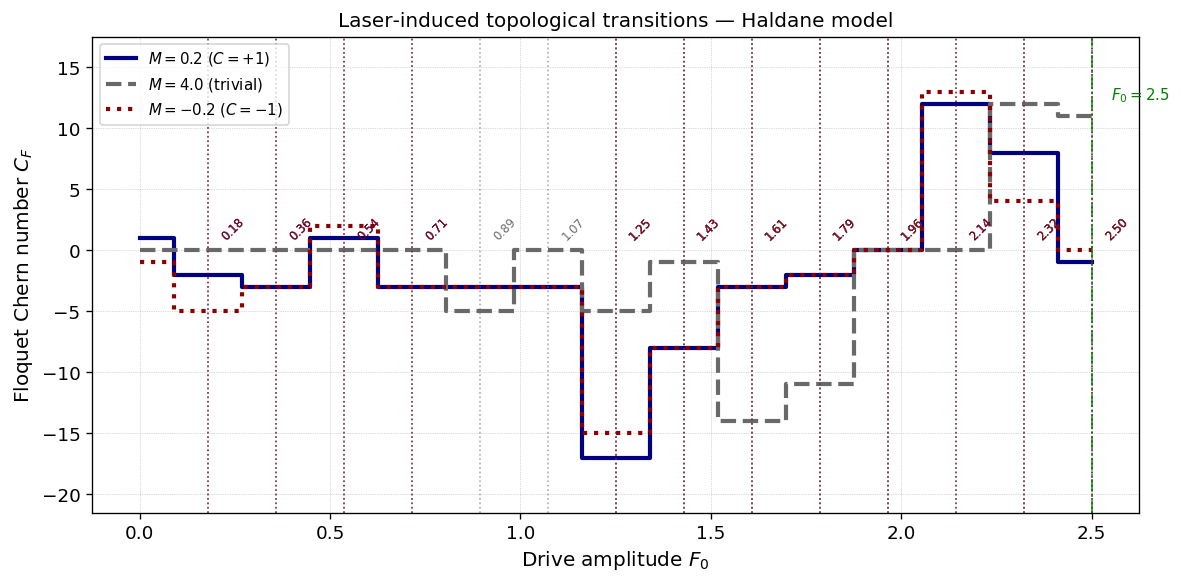

In [25]:
# ── Plot CF vs F0 ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

# Define labels and data
labels = [fr'$M={M_val}$ ($C=+1$)', fr'$M={M_triv}$ (trivial)', fr'$M={-M_val}$ ($C=-1$)']
data = [CF_C1, CF_triv, CF_neg]
colors = ['navy', 'dimgray', 'darkred']
styles = ['-', '--', ':']

for lbl, arr, col, ls in zip(labels, data, colors, styles):
    ax.step(F0_chern_scan, arr, where='mid',
            color=col, lw=2.5, ls=ls, label=lbl)
    # Find transitions (where Chern number changes)
    trans = F0_chern_scan[np.where(np.diff(arr) != 0)[0] + 1]
    for Ftr in trans:
        ax.axvline(Ftr, color=col, lw=1.0, ls=':', alpha=0.55)
        ax.text(Ftr + 0.03, 0.9, f'{Ftr:.2f}', color=col, fontsize=7,
                rotation=45, ha='left')

# Mark current F0 (global)
ax.axvline(F0, color='green', lw=1.2, ls='-.', alpha=0.7)
ax.text(F0 + 0.05, ax.get_ylim()[1] * 0.85, f'$F_0={F0}$',
        color='green', fontsize=9)

# Dynamic y‑range (no restriction)
ymin = min(np.nanmin(CF_C1), np.nanmin(CF_triv), np.nanmin(CF_neg))
ymax = max(np.nanmax(CF_C1), np.nanmax(CF_triv), np.nanmax(CF_neg))
padding = max(1, abs(ymax - ymin) * 0.15)
ax.set_ylim(ymin - padding, ymax + padding)

ax.set_xlabel(r'Drive amplitude $F_0$', fontsize=12)
ax.set_ylabel('Floquet Chern number $C_F$', fontsize=12)
ax.set_title('Laser‑induced topological transitions — Haldane model', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('Haldane_floquet_chern.png', dpi=150, bbox_inches='tight')
plt.show()

### 17. Transverse Hall Current Tracking

In [26]:
# ── Instantaneous σ_xy(t) proxy: anomalous velocity ──────────────────────
#
# σ_xy ∝ Σ_k Ω_z(k,A(t)) * (lower band occupancy)
# This is the instantaneous Berry curvature integral — proportional
# to the transverse (Hall) conductance and tracks Chern dynamics.

Nk_hall = 25
kx_hall = np.linspace(-2*np.pi/np.sqrt(3), 2*np.pi/np.sqrt(3),
                       Nk_hall, endpoint=False)
ky_hall = np.linspace(-np.pi, np.pi, Nk_hall, endpoint=False)
dkx_h   = kx_hall[1]-kx_hall[0]
dky_h   = ky_hall[1]-ky_hall[0]


def berry_curvature_map(M=M_val, Ax=0.0, Ay=0.0, Nk=Nk_hall):
    """Berry curvature Ω_z at each k via finite differences."""
    E_map = np.zeros((Nk, Nk))
    for i in range(Nk):
        for j in range(Nk):
            ev = np.linalg.eigvalsh(
                haldane_bloch_2x2(kx_hall[i], ky_hall[j], M,
                                   Ax=Ax, Ay=Ay))
            E_map[j, i] = ev[0]   # lower band

    dvydkx = np.gradient(E_map, dkx_h, axis=1)
    dvxdky = np.gradient(E_map, dky_h, axis=0)
    return dvydkx - dvxdky   # Ω_z ∝ curl of group velocity


# Track σ_xy(t) = (1/2π) ∫ Ω_z d²k  over one pulse + rampdown
n_track = 80
t_track = np.linspace(0, (n_cyc+4)*T_per, n_track)
sigma_xy_C1   = np.zeros(n_track)
sigma_xy_triv = np.zeros(n_track)

print("Computing Hall conductance tracking ...")
for f, tv in enumerate(t_track):
    if tv < t_max:
        Ax_v = (F0/omega)*np.cos(omega*tv)
        Ay_v = (F0/omega)*np.sin(omega*tv)
    else:
        Ax_v = 0.0;  Ay_v = 0.0
    Om_C1   = berry_curvature_map(M_val,  Ax_v, Ay_v)
    Om_triv = berry_curvature_map(M_triv, Ax_v, Ay_v)
    sigma_xy_C1[f]   = np.sum(Om_C1)   * dkx_h*dky_h / (2*np.pi)
    sigma_xy_triv[f] = np.sum(Om_triv) * dkx_h*dky_h / (2*np.pi)

Computing Hall conductance tracking ...


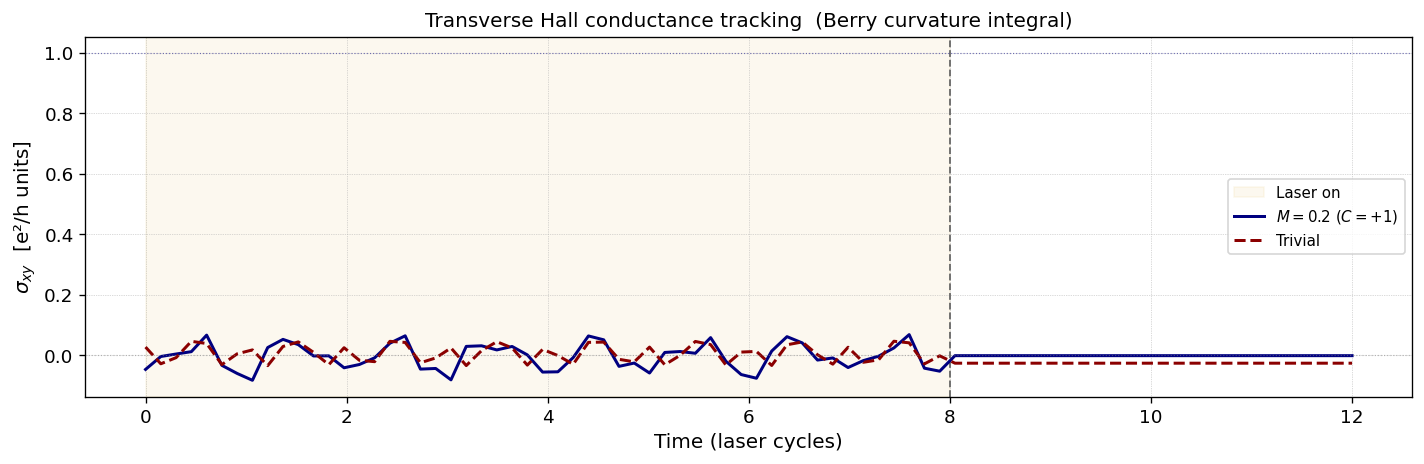

In [27]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.axvspan(0, n_cyc, alpha=0.07, color='goldenrod', label='Laser on')
ax.axvline(n_cyc, color='dimgray', lw=1.1, ls='--')
ax.plot(t_track/T_per, sigma_xy_C1,   color='navy',    lw=1.8,
        label=fr'$M={M_val}$ ($C=+1$)')
ax.plot(t_track/T_per, sigma_xy_triv, color='darkred', lw=1.8, ls='--',
        label='Trivial')
ax.axhline(1.0,  color='navy',    lw=0.7, ls=':', alpha=0.5)
ax.axhline(0.0,  color='gray',    lw=0.7, ls=':', alpha=0.5)
ax.set_xlabel('Time (laser cycles)', fontsize=12)
ax.set_ylabel(r'$\sigma_{xy}$  [e²/h units]', fontsize=12)
ax.set_title('Transverse Hall conductance tracking  (Berry curvature integral)',
             fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('Haldane_hall_tracking.png', dpi=150, bbox_inches='tight')
plt.show()

### 18. Phase Diagram: C_F vs (M, F₀)

In [ ]:
# 2D Floquet phase diagram  CF(M, F0)

M_pd2  = np.linspace(-3.0, 3.0, 16)
F0_pd2 = np.linspace(0.0,  2.5, 16)
CF_pd2 = np.zeros((len(F0_pd2), len(M_pd2)), dtype=int)

print("Computing Floquet phase diagram CF(M, F0) ...")
for fi, F0v in enumerate(F0_pd2):
    for mi, Mv in enumerate(M_pd2):
        CF_pd2[fi, mi] = floquet_chern_H(Mv, F0v, n_steps=60)
    print(f"  F0={F0v:.2f}  done")
print("Done.")

In [ ]:
# ---- Determine the range of Chern numbers present ----
cmin, cmax = CF_pd2.min(), CF_pd2.max()
nvals = cmax - cmin + 1

# Build a custom diverging colormap: blue for negative, white for zero, red for positive
from matplotlib.colors import ListedColormap, BoundaryNorm
if nvals <= 1:
    colors = ['white']
else:
    # Use RdBu_r (red for positive, blue for negative, white at zero)
    cmap_base = plt.cm.RdBu
    nneg = abs(cmin)  # number of negative values (excluding zero)
    npos = cmax       # number of positive values
    neg_positions = np.linspace(0.0, 0.48, nneg) if nneg > 0 else []
    pos_positions = np.linspace(0.52, 1.0, npos) if npos > 0 else []
    neg_colors = [cmap_base(p) for p in neg_positions]
    pos_colors = [cmap_base(p) for p in pos_positions]
    zero_color = (1.0, 1.0, 1.0, 1.0)
    colors = neg_colors + [zero_color] + pos_colors
cmap = ListedColormap(colors)
bounds = np.arange(cmin - 0.5, cmax + 0.6, 1)
norm = BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.pcolormesh(M_pd2, F0_pd2, CF_pd2,
                   cmap=cmap, norm=norm, shading='auto')
cbar = plt.colorbar(im, ax=ax, label='Floquet Chern number $C_F$',
                    ticks=np.arange(cmin, cmax + 1))

# Static boundaries: M = ±3√3 t2 sin(φ)
M_crit = 3 * np.sqrt(3) * t2_val * np.abs(np.sin(phi_val))
ax.axvline( M_crit, color='white', lw=1.2, ls='--', alpha=0.7,
            label=fr'$M=+{M_crit:.2f}$')
ax.axvline(-M_crit, color='white', lw=1.2, ls='--', alpha=0.7,
            label=fr'$M=-{M_crit:.2f}$')
ax.axvline(0, color='white', lw=0.8, ls=':', alpha=0.5)

ax.plot(M_val, F0, 'w^', ms=10, zorder=5,
        label=fr'Current  ($M={M_val}$,  $F_0={F0}$)')
ax.set_xlabel(r'Staggered mass $M$', fontsize=12)
ax.set_ylabel(r'Drive amplitude $F_0$', fontsize=12)
ax.set_title(
    r'Haldane Floquet phase diagram  ($\phi=\pi/2$,  circular drive)'
    '\n'
    r'Dashed: static Chern transition at $M=\pm 3\sqrt{3}\,t_2\sin\phi$',
    fontsize=12)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('Haldane_floquet_phase_diagram.png', dpi=150, bbox_inches='tight')
plt.show()

## HHG Analysis


### 20. Time Evolution — Coherent Propagation

In [29]:
# k-space density-matrix propagation — Haldane

Nk_hhg  = 25
kx_hhg  = np.linspace(-2*np.pi/np.sqrt(3), 2*np.pi/np.sqrt(3),
                       Nk_hhg, endpoint=False)
ky_hhg  = np.linspace(-np.pi, np.pi, Nk_hhg, endpoint=False)
KX_hhg2, KY_hhg2 = np.meshgrid(kx_hhg, ky_hhg, indexing='ij')


def build_rho0_H(M=M_val):
    rho0 = np.zeros((Nk_hhg, Nk_hhg, 2, 2), dtype=complex)
    for i in range(Nk_hhg):
        for j in range(Nk_hhg):
            _, evecs = np.linalg.eigh(
                haldane_bloch_2x2(kx_hhg[i], ky_hhg[j], M))
            v = evecs[:,0]
            rho0[i,j] = np.outer(v, v.conj())
    return rho0


def H_hhg_batch(Ax, Ay, M=M_val):
    H = np.zeros((Nk_hhg, Nk_hhg, 2, 2), dtype=complex)
    for i in range(Nk_hhg):
        for j in range(Nk_hhg):
            H[i,j] = haldane_bloch_2x2(
                KX_hhg2[i,j], KY_hhg2[i,j], M, Ax=Ax, Ay=Ay)
    return H


def Jx_hhg_batch(Ax, Ay):
    J = np.zeros((Nk_hhg, Nk_hhg, 2, 2), dtype=complex)
    for i in range(Nk_hhg):
        for j in range(Nk_hhg):
            J[i,j] = haldane_jx_2x2(
                KX_hhg2[i,j], KY_hhg2[i,j], Ax=Ax, Ay=Ay)
    return J


def Jy_hhg_batch(Ax, Ay):
    J = np.zeros((Nk_hhg, Nk_hhg, 2, 2), dtype=complex)
    for i in range(Nk_hhg):
        for j in range(Nk_hhg):
            J[i,j] = haldane_jy_2x2(
                KX_hhg2[i,j], KY_hhg2[i,j], Ax=Ax, Ay=Ay)
    return J


def time_evolve_H(M=M_val, verbose=True):
    """k-space RK4 evolution for Haldane model."""
    rho  = build_rho0_H(M)
    Jx_t = np.zeros(Nt)
    Jy_t = np.zeros(Nt)

    def comm(H, r):
        return -1j*(np.einsum('xyij,xyjl->xyil', H, r)
                   - np.einsum('xyij,xyjl->xyil', r, H))

    for step in range(Nt):
        Ax = A_x_arr[step];  Ay = A_y_arr[step]
        Jx_op = Jx_hhg_batch(Ax, Ay)
        Jy_op = Jy_hhg_batch(Ax, Ay)
        Jx_t[step] = np.real(np.einsum('xyij,xyji->', Jx_op, rho))/Nk_hhg**2
        Jy_t[step] = np.real(np.einsum('xyij,xyji->', Jy_op, rho))/Nk_hhg**2

        if step < Nt-1:
            Ax_n = A_x_arr[step+1];  Ay_n = A_y_arr[step+1]
            Ax_m = 0.5*(Ax+Ax_n);    Ay_m = 0.5*(Ay+Ay_n)
            k1 = comm(H_hhg_batch(Ax,  Ay,  M), rho)
            k2 = comm(H_hhg_batch(Ax_m,Ay_m,M), rho+0.5*dt*k1)
            k3 = comm(H_hhg_batch(Ax_m,Ay_m,M), rho+0.5*dt*k2)
            k4 = comm(H_hhg_batch(Ax_n,Ay_n,M), rho+     dt*k3)
            rho = rho + (dt/6.0)*(k1+2*k2+2*k3+k4)

        if verbose and step % (Nt//5) == 0:
            print(f"  step {step}/{Nt}  ({100*step/Nt:.0f}%)")
    return Jx_t, Jy_t


def compute_hhg_H(Jx, Jy):
    win  = np.hanning(len(Jx));  Nfft = 4*len(Jx)
    freqs = np.fft.rfftfreq(Nfft, d=dt)
    harm  = freqs/(omega/(2*np.pi))
    Fx = np.fft.rfft(Jx*win, n=Nfft)
    Fy = np.fft.rfft(Jy*win, n=Nfft)
    Fp = Fx+1j*Fy;  Fm = Fx-1j*Fy
    return (harm, np.abs(Fx)**2, np.abs(Fy)**2,
            np.abs(Fp)**2, np.abs(Fm)**2,
            np.abs(Fx)**2+np.abs(Fy)**2)


print(f"Evolving Haldane  M={M_val}  (C=+1) ...")
Jx_H1, Jy_H1 = time_evolve_H(M_val)

print(f"\nEvolving Haldane  M={M_triv}  (trivial) ...")
Jx_Ht, Jy_Ht = time_evolve_H(M_triv)

h_H1, Sxx_H1, Syy_H1, Sp_H1, Sm_H1, St_H1 = compute_hhg_H(Jx_H1, Jy_H1)
h_Ht, Sxx_Ht, Syy_Ht, Sp_Ht, Sm_Ht, St_Ht = compute_hhg_H(Jx_Ht, Jy_Ht)
print("Done.")

Evolving Haldane  M=0.2  (C=+1) ...
  step 0/3200  (0%)
  step 640/3200  (20%)
  step 1280/3200  (40%)
  step 1920/3200  (60%)
  step 2560/3200  (80%)

Evolving Haldane  M=4.0  (trivial) ...
  step 0/3200  (0%)
  step 640/3200  (20%)
  step 1280/3200  (40%)
  step 1920/3200  (60%)
  step 2560/3200  (80%)
Done.


### 21. HHG Power Spectrum (Longitudinal vs Transverse)

<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_58/127943229.py:35: SyntaxWarning: invalid escape sequence '\m'
  label='$S_\mathrm{tot}$ trivial', alpha=0.7)


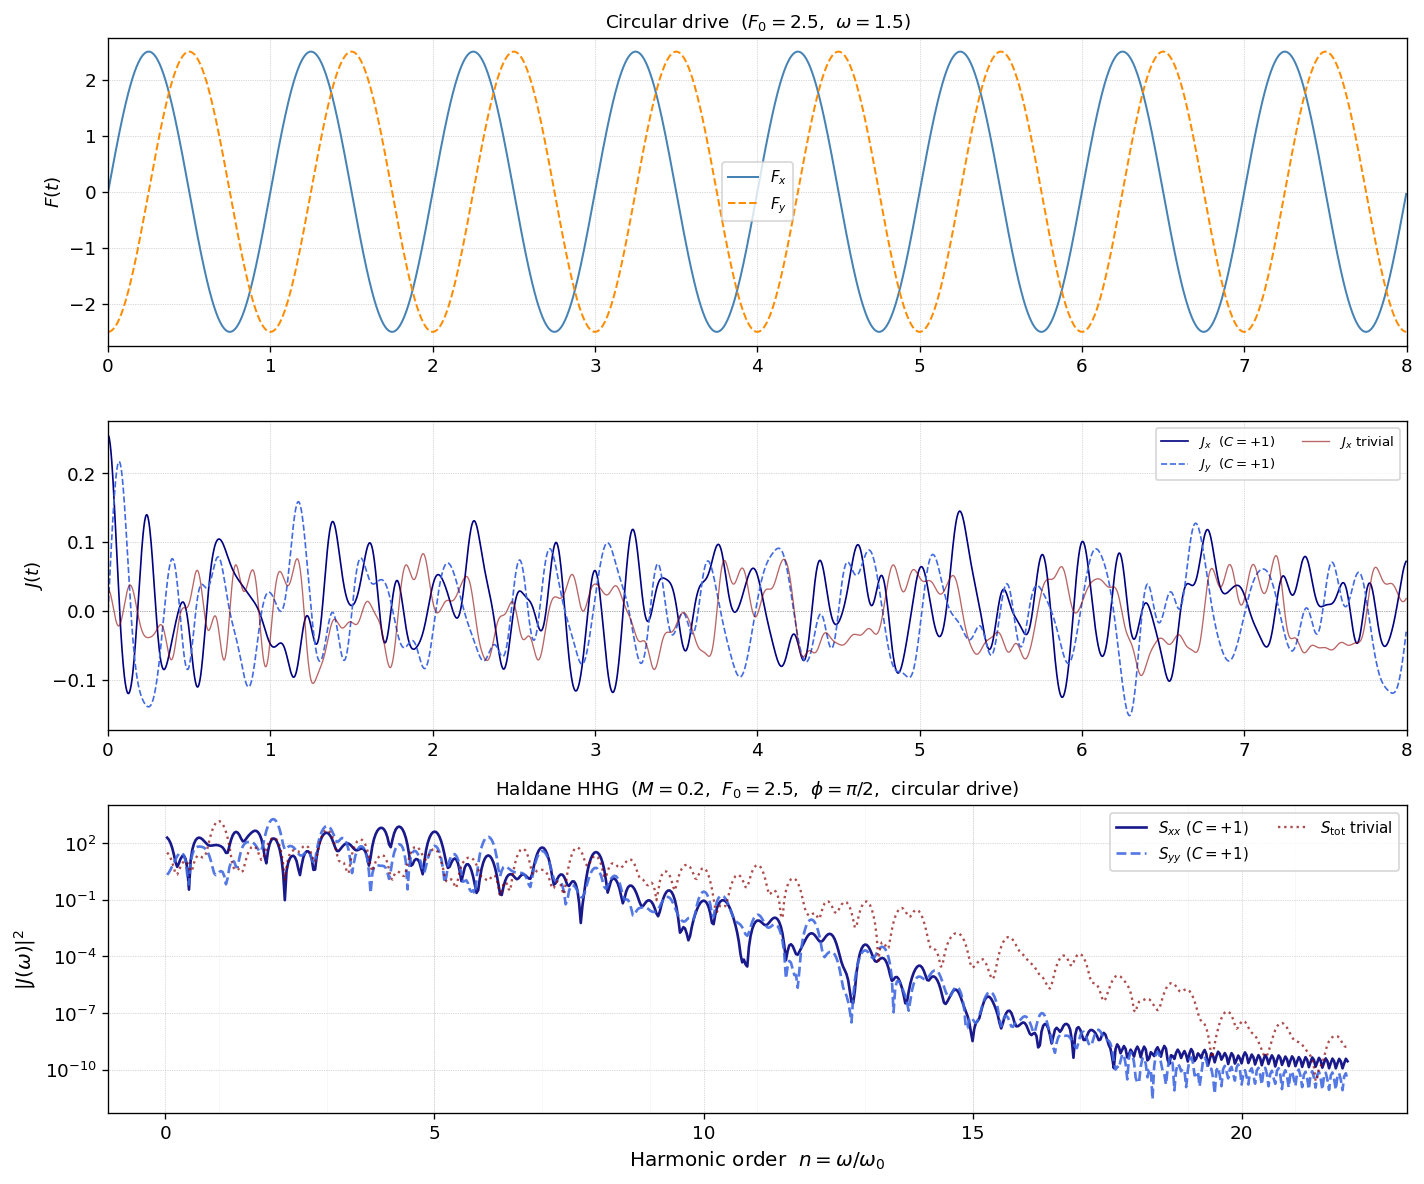

In [35]:
# Laser field, current, and HHG spectrum

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Field
ax = axes[0]
ax.plot(t_arr/T_per, F_x_arr, color='steelblue', lw=1.2, label='$F_x$')
ax.plot(t_arr/T_per, F_y_arr, color='darkorange', lw=1.2, ls='--', label='$F_y$')
ax.set_xlim(0, n_cyc)
ax.set_ylabel('$F(t)$', fontsize=11)
ax.set_title(fr'Circular drive  ($F_0={F0}$,  $\omega={omega}$)', fontsize=11)
ax.legend(fontsize=9)

# Current
ax = axes[1]
ax.plot(t_arr/T_per, Jx_H1, color='navy',      lw=1.0,
        label=fr'$J_x$  ($C=+1$)')
ax.plot(t_arr/T_per, Jy_H1, color='royalblue', lw=1.0, ls='--',
        label=fr'$J_y$  ($C=+1$)')
ax.plot(t_arr/T_per, Jx_Ht, color='darkred',   lw=0.8, alpha=0.6,
        label='$J_x$ trivial')
ax.axhline(0, color='gray', lw=0.4, ls=':')
ax.set_xlim(0, n_cyc)
ax.set_ylabel('$J(t)$', fontsize=11)
ax.legend(fontsize=8, ncol=2)

# HHG spectrum — longitudinal, transverse, total
ax = axes[2]
mask = (h_H1 > 0) & (h_H1 < 22)
ax.semilogy(h_H1[mask], Sxx_H1[mask], color='navy',    lw=1.6,
            label=r'$S_{xx}$ ($C=+1$)', alpha=0.9)
ax.semilogy(h_H1[mask], Syy_H1[mask], color='royalblue', lw=1.6, ls='--',
            label=r'$S_{yy}$ ($C=+1$)', alpha=0.9)
ax.semilogy(h_Ht[mask], St_Ht[mask],  color='darkred',   lw=1.4, ls=':',
            label='$S_\mathrm{tot}$ trivial', alpha=0.7)
for n in range(1, 22, 2):
    ax.axvline(n, color='gray', lw=0.3, alpha=0.3, ls=':')
ax.set_xlabel(r'Harmonic order  $n=\omega/\omega_0$', fontsize=12)
ax.set_ylabel(r'$|J(\omega)|^2$', fontsize=12)
ax.set_title(
    fr'Haldane HHG  ($M={M_val}$,  $F_0={F0}$,  $\phi=\pi/2$,  circular drive)',
    fontsize=11)
ax.legend(fontsize=9, ncol=2)

plt.tight_layout()
plt.savefig('Haldane_HHG_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()


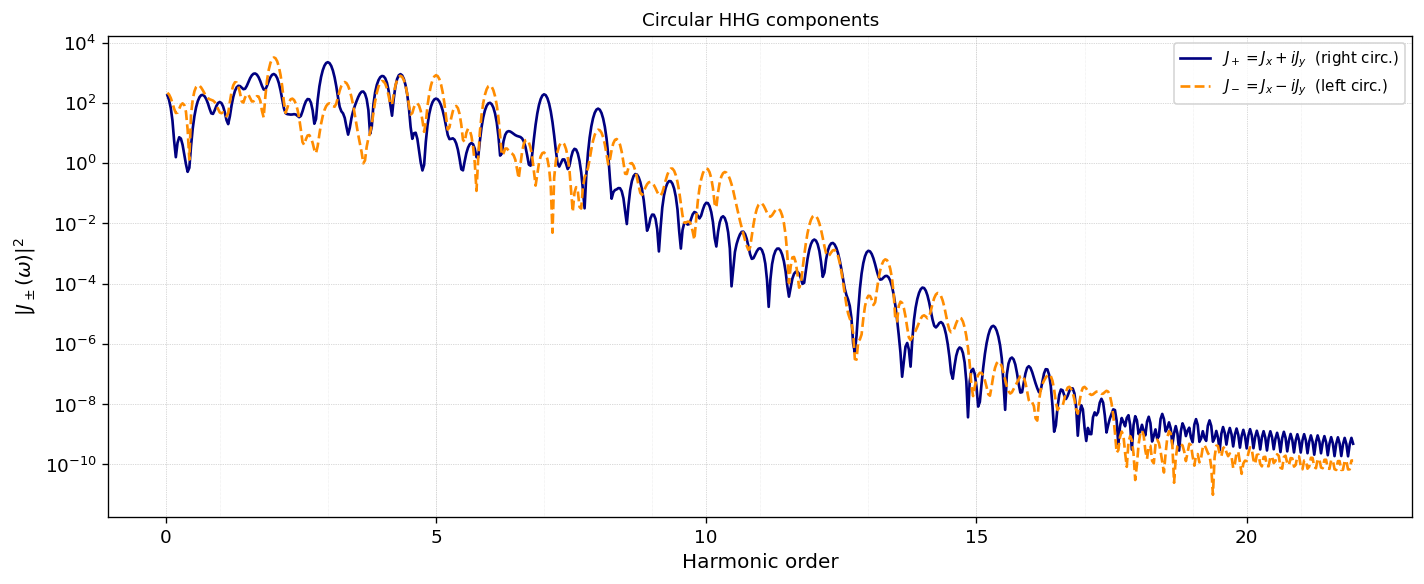

In [31]:
# Circular components J+/J-
fig, ax = plt.subplots(figsize=(12, 5))
ax.semilogy(h_H1[mask], Sp_H1[mask], color='navy',
            lw=1.6, label=r'$J_+ = J_x+iJ_y$  (right circ.)')
ax.semilogy(h_H1[mask], Sm_H1[mask], color='darkorange',
            lw=1.6, ls='--', label=r'$J_- = J_x-iJ_y$  (left circ.)')
for n in range(1, 22, 2):
    ax.axvline(n, color='gray', lw=0.3, alpha=0.3, ls=':')
ax.set_xlabel(r'Harmonic order', fontsize=12)
ax.set_ylabel(r'$|J_\pm(\omega)|^2$', fontsize=12)
ax.set_title(
    r'Circular HHG components',
    fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('Haldane_HHG_circular.png', dpi=150, bbox_inches='tight')
plt.show()

### 22. Odd vs Even Harmonic Decomposition

In [32]:
# ── Odd/even decomposition ────────────────────────────────────────────────
#
# C3 symmetry of honeycomb:
#  - Odd harmonics: always present
#  - Even harmonics: activated by M≠0 (inversion breaking)
#                    AND by circular drive (TR breaking)
#  - Harmonic 3n: suppressed by C3 (forbidden in pure graphene)
#
# With circular drive:
#   J_+ carries harmonics 3n+1 (right circular)
#   J_- carries harmonics 3n-1 (left circular) = 3n+2

def harmonic_bar_H(harm, S, n_max=18):
    ns = np.arange(1, n_max+1)
    I  = np.array([
        np.max(S[(harm>=n-0.4)&(harm<=n+0.4)])
        if ((harm>=n-0.4)&(harm<=n+0.4)).any() else 1e-40
        for n in ns])
    return ns, I

ns1,  Is1  = harmonic_bar_H(h_H1, St_H1)
nst,  Ist  = harmonic_bar_H(h_Ht, St_Ht)
ns1p, Is1p = harmonic_bar_H(h_H1, Sp_H1)
ns1m, Is1m = harmonic_bar_H(h_H1, Sm_H1)

# C3 selection: multiples of 3
c3_mask   = (ns1 % 3 == 0)
odd_mask  = (ns1 % 2 == 1) & ~c3_mask
even_mask = (ns1 % 2 == 0) & ~c3_mask

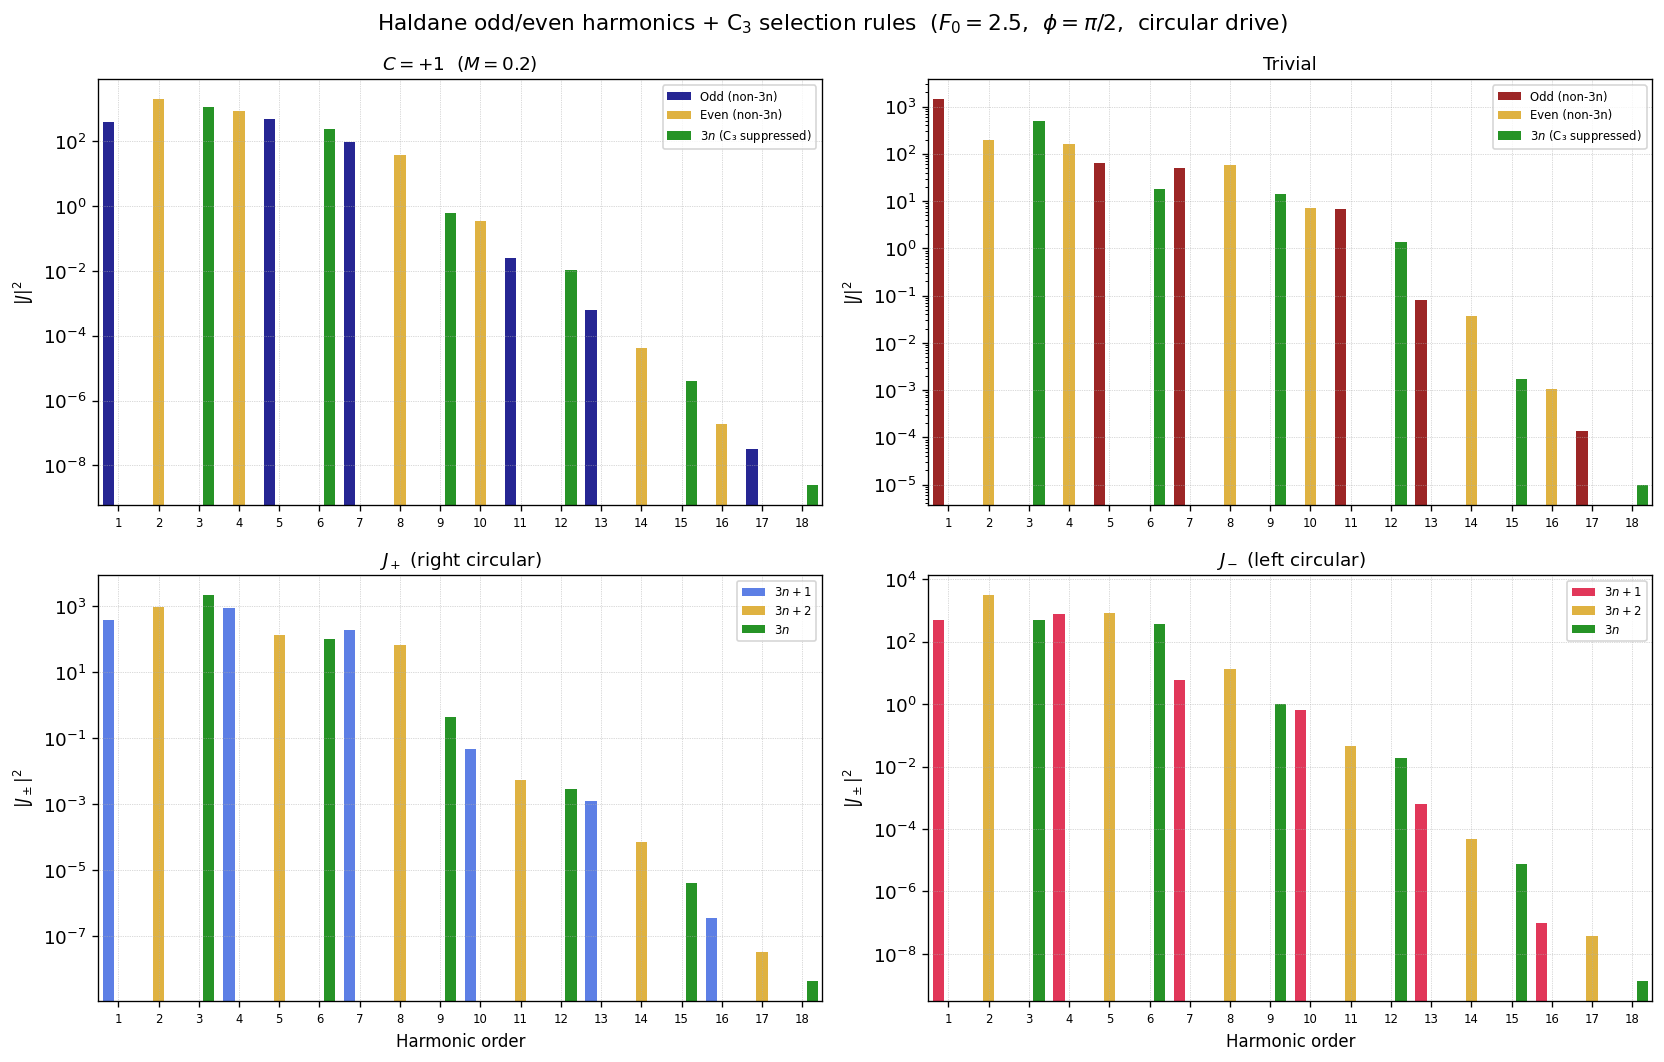

In [33]:
fig, axes_oe = plt.subplots(2, 2, figsize=(14, 9))

for ax, ns, Is, plbl, col in zip(
        axes_oe[0], [ns1, nst], [Is1, Ist],
        [fr'$C=+1$  ($M={M_val}$)', 'Trivial'], ['navy','darkred']):
    ax.bar(ns[odd_mask ]-0.25, Is[odd_mask],  width=0.28,
           color=col,      alpha=0.85, label='Odd (non-3n)')
    ax.bar(ns[even_mask]+0.0,  Is[even_mask], width=0.28,
           color='goldenrod', alpha=0.85, label='Even (non-3n)')
    ax.bar(ns[c3_mask  ]+0.25, Is[c3_mask],   width=0.28,
           color='green',  alpha=0.85, label='$3n$ (C₃ suppressed)')
    ax.set_yscale('log');  ax.legend(fontsize=7)
    ax.set_xticks(ns);  ax.set_xticklabels([str(n) for n in ns], fontsize=7)
    ax.set_xlim(0.5, 18.5);  ax.set_title(plbl, fontsize=11)
    ax.set_ylabel(r'$|J|^2$', fontsize=10)
    ax.grid(True, ls=':', lw=0.4, axis='y')

for ax, ns, Is, lbl, col in zip(
        axes_oe[1], [ns1p, ns1m], [Is1p, Is1m],
        [r'$J_+$ (right circular)', r'$J_-$ (left circular)'],
        ['royalblue','crimson']):
    # 3n+1 and 3n+2 groups
    g1_mask = (ns % 3 == 1)   # 1,4,7,10,... → right circular
    g2_mask = (ns % 3 == 2)   # 2,5,8,11,... → left circular
    g0_mask = (ns % 3 == 0)
    ax.bar(ns[g1_mask]-0.25, Is[g1_mask], width=0.28,
           color=col, alpha=0.85, label='$3n+1$')
    ax.bar(ns[g2_mask]+0.0,  Is[g2_mask], width=0.28,
           color='goldenrod', alpha=0.85, label='$3n+2$')
    ax.bar(ns[g0_mask]+0.25, Is[g0_mask], width=0.28,
           color='green', alpha=0.85, label='$3n$')
    ax.set_yscale('log');  ax.legend(fontsize=7)
    ax.set_xticks(ns);  ax.set_xticklabels([str(n) for n in ns], fontsize=7)
    ax.set_xlim(0.5, 18.5);  ax.set_title(lbl, fontsize=11)
    ax.set_ylabel(r'$|J_\pm|^2$', fontsize=10)
    ax.set_xlabel('Harmonic order', fontsize=10)
    ax.grid(True, ls=':', lw=0.4, axis='y')

fig.suptitle(
    fr'Haldane odd/even harmonics + C$_3$ selection rules  '
    fr'($F_0={F0}$,  $\phi=\pi/2$,  circular drive)',
    fontsize=13)
plt.tight_layout()
plt.savefig('Haldane_HHG_odd_even.png', dpi=150, bbox_inches='tight')
plt.show()